# Customer Segmentation Project

**Unsupervised customer segmentation for a retail marketing team, built as a production-style ML pipeline rather than a one-off notebook.**

K-Means clustering on ~2,200 retail customers, split into 5 actionable segments (e.g. *High-Value Customers*, *Deal-Seeking Large Families*) based on spending, purchase channel, and household composition. The winning pipeline (`StandardScaler` → `PCA` → `KMeans`, k=5) is checked against silhouette, Davies-Bouldin, and Calinski-Harabasz scores, then validated for stability with two independent tests (seed ARI 0.998, bootstrap ARI 0.948) before being served through a FastAPI endpoint and Streamlit app — see the [repo README](https://github.com/Ampofowaa/CustomerSegmentation_Project) for the full system.

**Repo:** [github.com/Ampofowaa/CustomerSegmentation_Project](https://github.com/Ampofowaa/CustomerSegmentation_Project)

---

**How to read this notebook:** every modeling decision below — which rows to drop, which features to keep, how many clusters to use, whether to add PCA — is backed by an explicit **Decision** call with both statistical and business evidence, not a metric read in isolation. Start with [Business Goal](#Business-Goal) for the *why*, jump to [Cluster Interpretation](#Cluster-Interpretation) for the final segments and their business read, or use the [Table of Contents](#Table-of-Contents) below to jump to any step.

## Table of Contents

**Short on time?** Jump straight to [Cluster Interpretation](#Cluster-Interpretation) for the final segments, or [Summary \& Next Steps](#Summary-&-Next-Steps) at the end.

- [Business Goal](#Business-Goal)
- [Notebook Purpose & Scope](#Notebook-Purpose-&-Scope)
- [Data Loading](#Data-Loading)
- [Exploratory Data Analysis (Raw Data)](#Exploratory-Data-Analysis-(Raw-Data))
  - [Missing Data Checks](#Missing-Data-Checks)
  - [Univariate Distributions](#Univariate-Distributions)
  - [Outlier Detection](#Outlier-Detection)
- [Data Cleaning](#Data-Cleaning)
- [Feature Engineering](#Feature-Engineering)
  - [Pearson Correlation Check](#Pearson-Correlation-Check)
  - [Feature Rationale](#Feature-Rationale)
- [Feature Selection](#Feature-Selection)
  - [Correlation Setup](#Correlation-Setup)
  - [Demographics (Age, Teenhome, Kidhome, TotalNo_Children)](#Demographics-(Age,-Teenhome,-Kidhome,-TotalNo_Children))
  - [Monetary Value (Income, Total_Spending, Avg_Spend_Per_Purchase)](#Monetary-Value-(Income,-Total_Spending,-Avg_Spend_Per_Purchase))
  - [Recency, Tenure & Complaints (Recency, Customer_Tenure, Complain)](#Recency,-Tenure-&-Complaints-(Recency,-Customer_Tenure,-Complain))
  - [Purchase Channel (NumWebPurchases, NumWebVisitsMonth, NumStorePurchases, NumCatalogPurchases)](#Purchase-Channel-(NumWebPurchases,-NumWebVisitsMonth,-NumStorePurchases,-NumCatalogPurchases))
  - [Promotion Responsiveness (NumDealsPurchases, Total_Campaigns_Accepted / AcceptedCmp1–5 / Response)](#Promotion-Responsiveness-(NumDealsPurchases,-Total_Campaigns_Accepted-/-AcceptedCmp1–5-/-Response))
  - [Resulting Feature Set](#Resulting-Feature-Set)
- [Model Training](#Model-Training)
  - [Choosing the Number of Clusters (K)](#Choosing-the-Number-of-Clusters-(K))
  - [Experiment A: Fit & Evaluate — No PCA](#Experiment-A:-Fit-&-Evaluate-—-No-PCA)
  - [Experiment B: Fit & Evaluate — With PCA](#Experiment-B:-Fit-&-Evaluate-—-With-PCA)
  - [Compare Experiments & Select Final Artifact](#Compare-Experiments-&-Select-Final-Artifact)
  - [Fitting Final Pipeline](#Fitting-Final-Pipeline)
- [Final Model Evaluation](#Final-Model-Evaluation)
  - [Cluster Validity Checks](#Cluster-Validity-Checks)
  - [Cluster Profile](#Cluster-Profile)
  - [Cluster Interpretation](#Cluster-Interpretation)
- [Artifacts](#Artifacts)
- [Summary & Next Steps](#Summary-&-Next-Steps)

## Business Goal

**Problem:** Marketing currently sends the same campaigns to the entire customer base. Response rates are low because a single offer doesn't fit a customer who buys weekly online and a customer who hasn't purchased in months.

**Goal:** Segment customers into a small number of groups the marketing team can target differently — e.g. loyalty/upsell offers for high-value customers, win-back campaigns for inactive customers, and channel-specific promotions for web-heavy vs. store-heavy shoppers. The output should let a marketer look up a customer (existing or new) and get a segment label they can act on, not just a cluster number.

**Who uses this:** the marketing/CRM team, via the Streamlit app (`app/segmentation.py`) or a batch export of segment labels for the CRM.

**Success criteria:**
- Clusters are separable enough to be meaningfully different (silhouette score, not just an elbow-plot bend).
- Cluster sizes are large enough to justify a targeted campaign — no clusters of a handful of customers.
- Each cluster's profile maps to a clear, plain-English description a non-technical stakeholder can read and act on (see `config.CLUSTER_NAMES`).
- Results are reproducible: re-running training on the same data should not silently reshuffle which customers land in which segment (`config.RANDOM_STATE`).

**Out of scope for this notebook:** deciding *what* each segment's campaign should be — that's a marketing decision made from the cluster profile below, not a modeling one.

## Notebook Purpose \& Scope

This notebook is for **exploration and justification only**. All production logic (cleaning, feature engineering, model training) lives in `src/` and is imported here rather than duplicated, so this notebook can never drift out of sync with the pipeline that actually runs in `scripts/train.py` and `app/segmentation.py`.

### Setup

Standard libraries plus the production functions from `src/` and `config` that this notebook exercises throughout — nothing below is reimplemented locally.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `config` and `src` resolve from notebooks/

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

import config
from src.data.loader import clean_data, load_raw_data
from src.features.engineer import engineer_features
from src.models.train import (
    check_bootstrap_stability,
    check_cluster_stability,
    cluster_profile,
    evaluate_k_range,
    fit_pipeline,
)
from src.pipeline import run_training_pipeline


## Data Loading

In [2]:
df_raw = load_raw_data()
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

## Exploratory Data Analysis (Raw Data)

Before deciding how to handle missing values or cap outliers, look at the distributions directly rather than assuming which values are "extreme". This is univariate and bivariate EDA on the **raw, unfiltered** data.

In [3]:
id_cols = ["ID"]
constant_cols = ["Z_CostContact", "Z_Revenue"]  # single unique value each, no signal
binary_cols = [
    "Complain",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5",
    "Response",
]
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()
numeric_cols = [
    c for c in df_raw.select_dtypes(include="number").columns
    if c not in id_cols + constant_cols + binary_cols
]

# Human-readable chart labels, so plot titles read as what the column means
# rather than the raw dataframe name -- see the column glossary in the README.
COLUMN_LABELS = {
    "Year_Birth": "Year of Birth",
    "Income_Thousands": "Income ($ thousands)",
    "Kidhome": "Number of Children (Kidhome)",
    "Teenhome": "Number of Teenagers (Teenhome)",
    "Recency": "Days Since Last Purchase (Recency)",
    "MntWines": "Wine Spend, Last 2 Yrs (MntWines)",
    "MntFruits": "Fruit Spend, Last 2 Yrs (MntFruits)",
    "MntMeatProducts": "Meat Spend, Last 2 Yrs (MntMeatProducts)",
    "MntFishProducts": "Fish Spend, Last 2 Yrs (MntFishProducts)",
    "MntSweetProducts": "Sweets Spend, Last 2 Yrs (MntSweetProducts)",
    "MntGoldProds": "Gold Product Spend, Last 2 Yrs (MntGoldProds)",
    "NumDealsPurchases": "Discounted Purchases (NumDealsPurchases)",
    "NumWebPurchases": "Web Purchases (NumWebPurchases)",
    "NumCatalogPurchases": "Catalog Purchases (NumCatalogPurchases)",
    "NumStorePurchases": "Store Purchases (NumStorePurchases)",
    "NumWebVisitsMonth": "Web Visits Last Month (NumWebVisitsMonth)",
    "Complain": "Complained in Last 2 Yrs (Complain)",
    "AcceptedCmp1": "Accepted Campaign 1 (AcceptedCmp1)",
    "AcceptedCmp2": "Accepted Campaign 2 (AcceptedCmp2)",
    "AcceptedCmp3": "Accepted Campaign 3 (AcceptedCmp3)",
    "AcceptedCmp4": "Accepted Campaign 4 (AcceptedCmp4)",
    "AcceptedCmp5": "Accepted Campaign 5 (AcceptedCmp5)",
    "Response": "Accepted Last Campaign (Response)",
}


### Missing Data Checks

In [4]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({"missing": missing, "missing_%": missing_pct})

# Only columns that actually have missing values -- with 29 raw columns, showing
# the full table just to say "0" 28 times buries the one column that matters.
missing_summary[missing_summary["missing"] > 0]


,missing,missing_%
Income,24,1.07


`Income` is the only column with missing values (~1% of rows). At that share, dropping the affected rows is simpler than imputing and won't meaningfully shrink the dataset — `clean_data()` drops them and logs the count.

### Univariate Distributions

Distributions of the raw columns, split into the three groups defined above: continuous **Numeric**, 0/1 **Binary / Flag**, and multi-level **Multi-Categorical**.

#### Numeric

All continuous numeric columns (`numeric_cols` — excludes `ID`, the constant `Z_CostContact`/`Z_Revenue` columns, and the binary/flag columns covered next).

In [5]:
# Transposed (.T) so every column becomes a row -- with this many numeric
# columns, the untransposed table truncates and hides some of them.
df_raw[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0


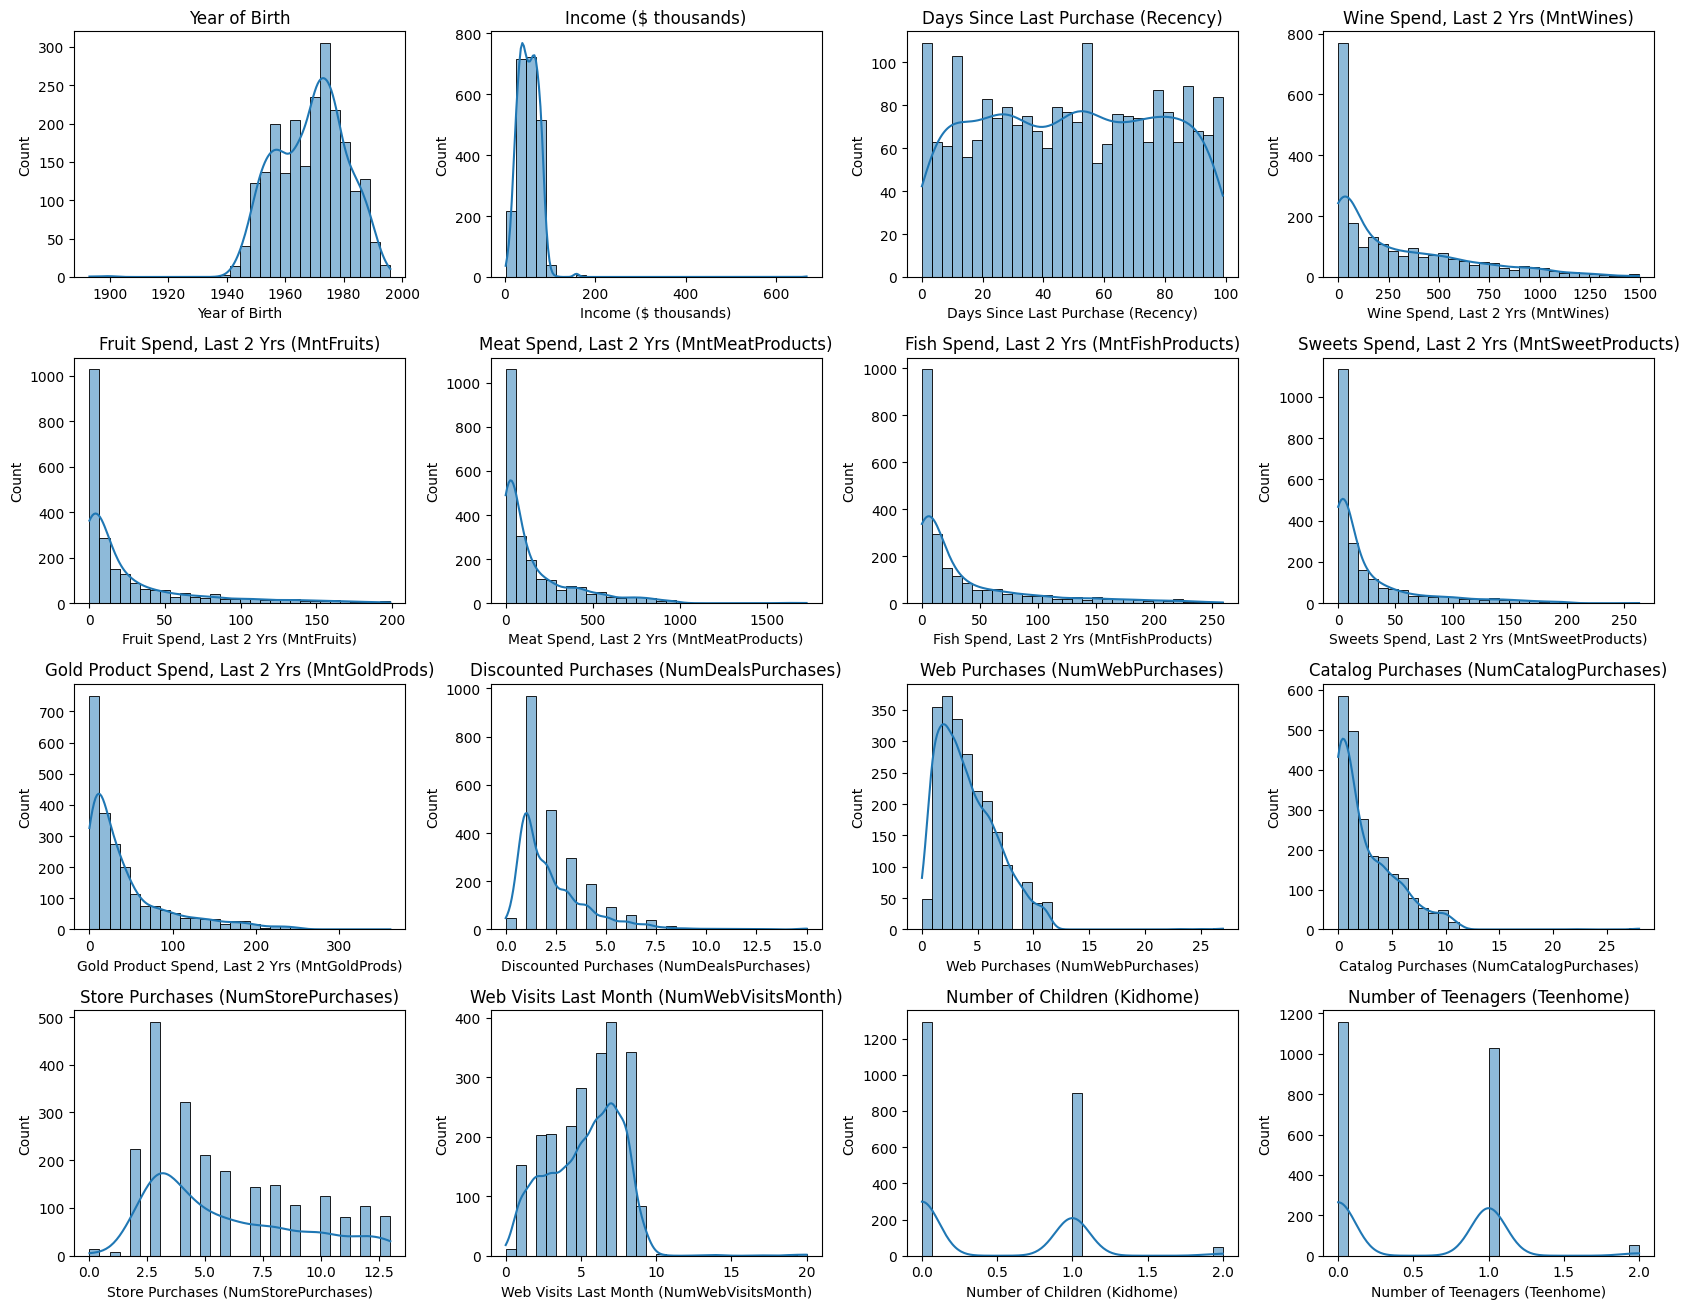

In [6]:
df_eda = df_raw.copy()
df_eda["Income_Thousands"] = df_eda["Income"] / 1_000

numeric_hist_cols = [
    "Year_Birth", "Income_Thousands", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Kidhome", "Teenhome",
]

n_cols = 4
n_rows = -(-len(numeric_hist_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.3 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, numeric_hist_cols):
    label = COLUMN_LABELS.get(col, col)
    sns.histplot(df_eda[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)
for ax in axes[len(numeric_hist_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


**Demographics & engagement** (**Year of Birth**, **Income**, **Number of Children** / **Number of Teenagers**, **Days Since Last Purchase**) — **Year of Birth** (`Year_Birth`) is left-skewed and centers on customers born in the 1940s–1990s (mean 1969), with a handful of implausibly old outliers (min 1893) revisited in [Outlier Detection](#Outlier-Detection). **Income** (`Income`) is heavily right-skewed — median (\$51.4k) sits close to the mean (\$52.2k), but the max of \$666,666 is a single extreme outlier also handled later. **Number of Children** (`Kidhome`) / **Number of Teenagers** (`Teenhome`) are discrete counts (0–2 per household, mean ~0.44 and ~0.51) rather than continuous spend/behavior measures, but they're grouped here as numeric since they aren't simple 0/1 flags. **Days Since Last Purchase** (`Recency`) is close to uniform across its 0–99 range — no skew, no obvious concentration at either end.

**Spending** (**Wine**, **Fruit**, **Meat**, **Fish**, **Sweets**, **Gold Product** spend, last 2 years — the `Mnt*` columns) — all six are strongly right-skewed: for every one of them the median is far below the mean (e.g. **Wine Spend** (`MntWines`) median \$173.50 vs. mean \$303.94; **Fruit Spend** (`MntFruits`) median \$8 vs. mean \$26.30), meaning most customers spend little in a given category while a smaller group of high spenders pulls the average up and produces the long tail visible in the histograms. **Wine Spend** and **Meat Spend** (`MntMeatProducts`) have both the highest spend and the widest spread (up to \$1,493 and \$1,725), so they'll dominate any distance-based comparison unless scaled — the reason `Total_Spending` is engineered as a single aggregate later rather than feeding all six raw columns into the model.

**Purchase channels & visits** (**Discounted**, **Web**, **Catalog**, **Store** purchases, and **Web Visits Last Month** — the `Num*` columns) — less extreme skew than the spend group, but still right-skewed for the purchase counts. **Store Purchases** (`NumStorePurchases`) has the highest average engagement (mean 5.79) of the three purchase channels, **Catalog Purchases** (`NumCatalogPurchases`) the lowest (mean 2.66), with **Web Purchases** (`NumWebPurchases`) in between (mean 4.08) — store remains the primary channel for this customer base. **Web Visits Last Month** (`NumWebVisitsMonth`) looks the most bell-shaped of this group (mean 5.32, tighter spread), reflecting browsing behavior rather than a purchase count.

#### Binary / Flag Variables

`Complain`, `AcceptedCmp1`–`5`, and `Response` (`binary_cols`) are 0/1 flags, not continuous quantities — shown as rates and counts below rather than histograms.

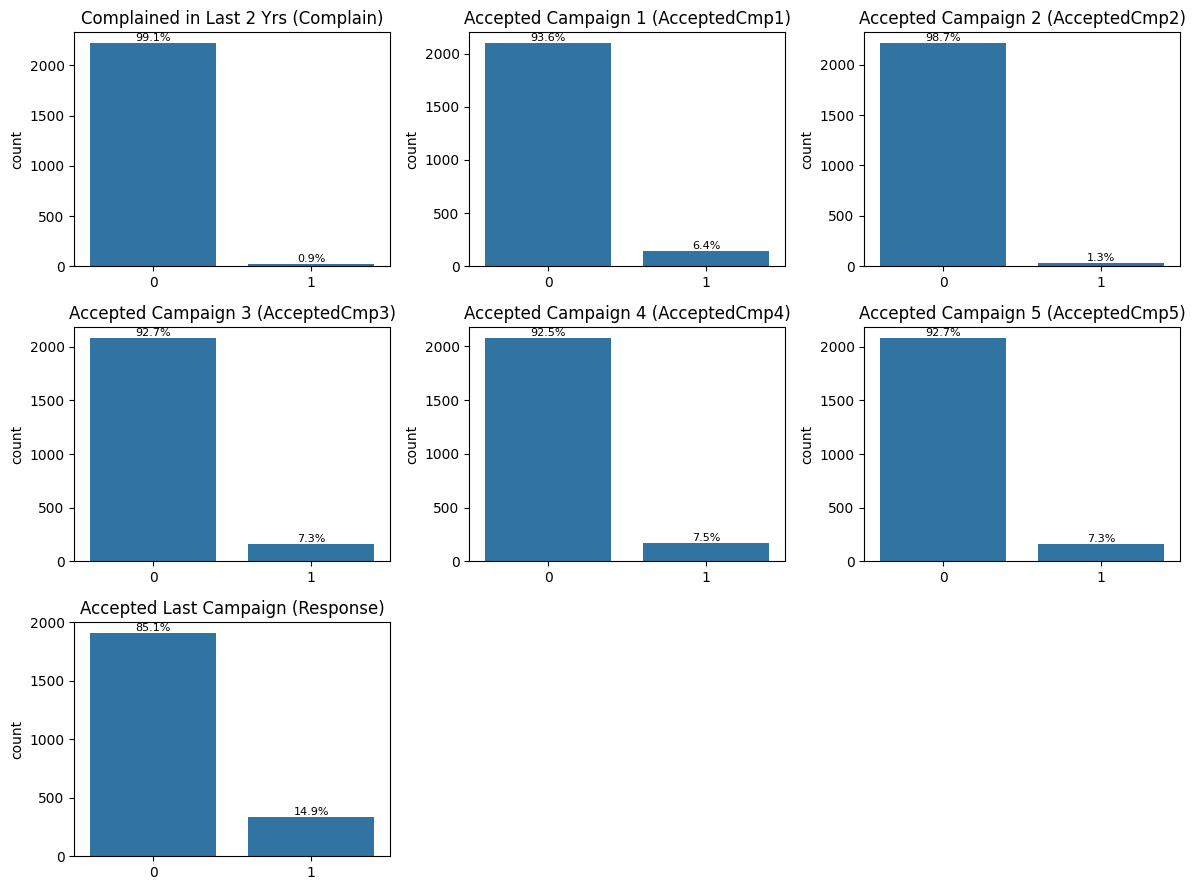

In [7]:
n_cols = 3
n_rows = -(-len(binary_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, binary_cols):
    sns.countplot(x=df_eda[col], ax=ax)
    ax.set_title(COLUMN_LABELS.get(col, col))
    ax.set_xlabel("")
    total = len(df_eda[col])
    for bar in ax.patches:
        pct = 100 * bar.get_height() / total
        ax.annotate(
            f"{pct:.1f}%",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=8,
        )
for ax in axes[len(binary_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


**Complained in Last 2 Yrs** (`Complain`) is the rarest positive of the group at 0.9% — the overwhelming majority of customers (99.1%) had no formal complaint in the window, a reassuring signal on customer satisfaction and one this dataset doesn't otherwise surface (no CSAT/NPS field to cross-check it against).

**Accepted Campaign 1–5** (`AcceptedCmp1`–`AcceptedCmp5`) record whether a customer took up each of five *historical* marketing campaigns. Four of the five land in a tight 6.4%–7.5% band (`AcceptedCmp1` 6.4%, `AcceptedCmp3` 7.3%, `AcceptedCmp4` 7.5%, `AcceptedCmp5` 7.3%) — similar performance across most campaigns. `AcceptedCmp2` is the outlier at just 1.3%, well below the others, suggesting that particular campaign or offer landed poorly regardless of who it targeted.

**Accepted Last Campaign** (`Response`) — whether the customer took up the most recent campaign — has the highest acceptance rate by a clear margin at 14.9%, roughly double the best of the five historical campaigns. That gap is worth keeping in mind: it could mean the most recent offer/targeting was simply more effective, or that `Response` was measured differently (e.g. a longer observation window) than `AcceptedCmp1`–`5`.

#### Multi-Categorical

`Education` and `Marital_Status` (`categorical_cols`) are the two object-dtype columns, each with more than two levels.

In [8]:
df_raw[categorical_cols].describe()


,Education,Marital_Status
count,2240,2240
unique,5,8
top,Graduation,Married
freq,1127,864


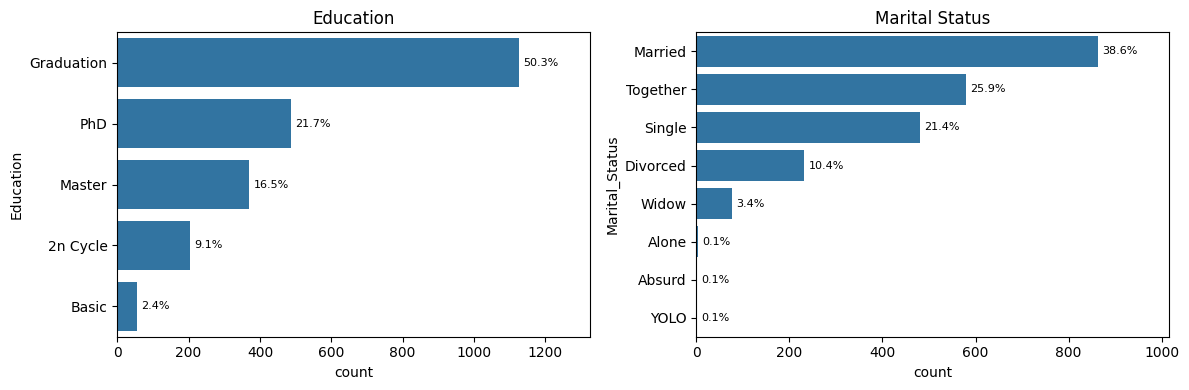

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(y="Education", data=df_raw, order=df_raw["Education"].value_counts().index, ax=axes[0])
axes[0].set_title("Education")
sns.countplot(y="Marital_Status", data=df_raw, order=df_raw["Marital_Status"].value_counts().index, ax=axes[1])
axes[1].set_title("Marital Status")
for ax, col in zip(axes, ["Education", "Marital_Status"]):
    total = len(df_raw[col])
    for bar in ax.patches:
        pct = 100 * bar.get_width() / total
        ax.annotate(
            f"{pct:.1f}%",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            ha="left", va="center", fontsize=8, xytext=(3, 0), textcoords="offset points",
        )
    # Give the largest bar's label room so it isn't clipped by the axis edge.
    ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.show()


**Education** (`Education`) — five levels, heavily concentrated in **Graduation** (50.3%) and **PhD** (21.7%), with **Master** (16.5%), **2n Cycle** (9.1%), and **Basic** (2.4%) trailing. No data-quality concerns — every value is a plausible education level.

**Marital Status** (`Marital_Status`) — reports **8** unique values, not the expected ~5. Alongside the sensible **Married** (38.6%), **Together** (25.9%), **Single** (21.4%), **Divorced** (10.4%), and **Widow** (3.4%), there are three near-empty categories — **Alone**, **Absurd**, and **YOLO** — each at 0.1% (2–3 rows), almost certainly free-text/placeholder entries from an unvalidated form field rather than real marital statuses.

### Outlier Detection

The histograms above hinted at a long right tail on `Income` and the boxplots below make it (and a handful of implausibly old `Year_Birth` values) easier to spot precisely — first on their own, then `Income` broken out by Education/Marital_Status to check whether that outlier concentrates in a particular group or is an isolated data-entry issue.

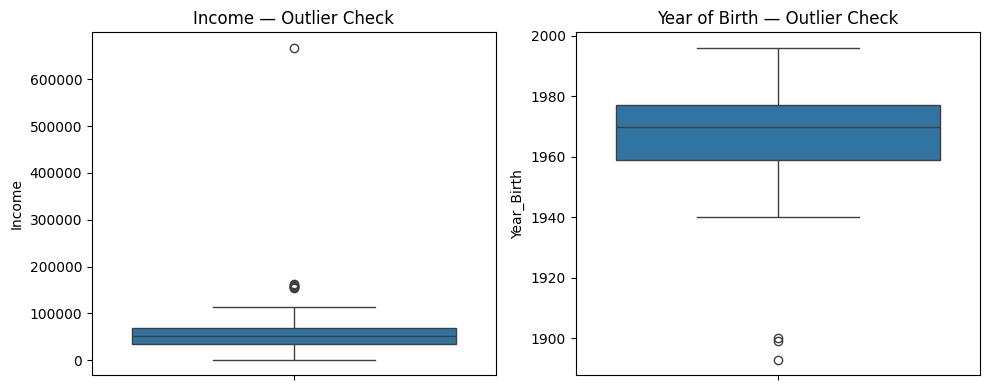

,Income
min,1730.0
25%,35303.0
75%,68522.0
max,666666.0
ID,Year_Birth
7829,1900
11004,1893
1150,1899


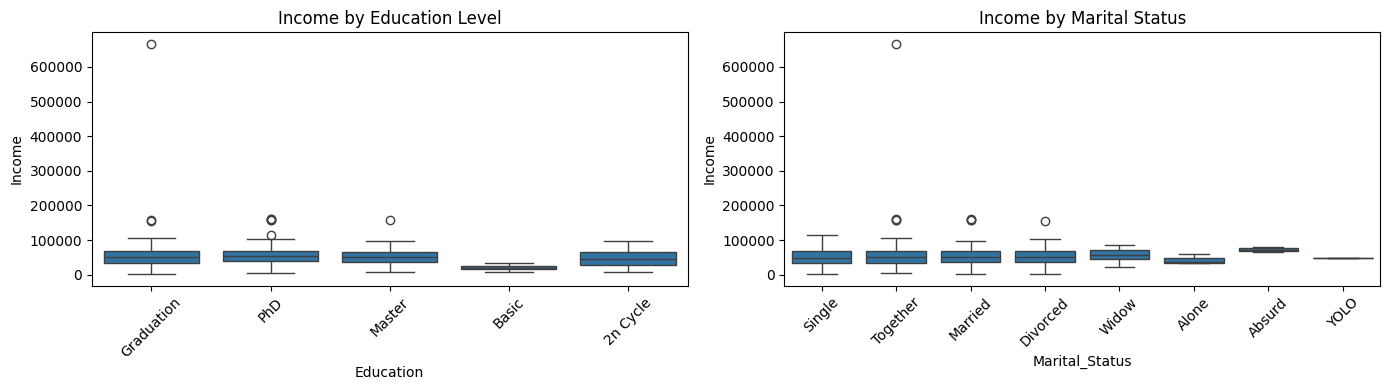

In [10]:
from IPython.display import display_html

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_eda["Income"].dropna(), ax=axes[0]).set_title("Income — Outlier Check")
sns.boxplot(y=df_eda["Year_Birth"], ax=axes[1]).set_title("Year of Birth — Outlier Check")
plt.tight_layout()
plt.show()

income_stats = df_eda["Income"].describe().loc[["min", "25%", "75%", "max"]].to_frame(name="Income")
birth_outliers = df_eda.loc[df_eda["Year_Birth"] < 1940, ["ID", "Year_Birth"]]

display_html(
    '<div style="display:flex; gap:60px;">'
    f'<div><b>Income (key stats)</b>{income_stats.to_html()}</div>'
    f'<div><b>Rows with implausible Year_Birth (&lt; 1940)</b>{birth_outliers.to_html(index=False)}</div>'
    '</div>',
    raw=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x="Education", y="Income", data=df_eda, ax=axes[0])
axes[0].set_title("Income by Education Level")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Marital_Status", y="Income", data=df_eda, ax=axes[1])
axes[1].set_title("Income by Marital Status")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Both outliers get **capped, not dropped** — the customer's other features (spending, channel behavior, etc.) are still valid signal, so dropping the row would throw away good data along with the one bad value. The evidence for each:

- **Income** — one customer reports `Income = 666,666`, vs. a 75th percentile of `68,522` (≈9.7x the top of the interquartile range). It shows up as a single, isolated point far above the rest of the boxplot — the next-highest points cluster near \$150k–160k, clearly separated from it — and would single-handedly dominate any Euclidean-distance-based clustering (K-Means) if left in. `config.INCOME_MAX = 200_000` caps it accordingly.
- **Year_Birth** — three customers have `Year_Birth` of 1893, 1899, and 1900, implying ages over 120 in the current data. These sit as clear low outliers on the boxplot, separated from the rest of the distribution which starts at 1940. `config.AGE_MAX = 90` caps these to the equivalent of a 90-year-old.
- The Income outlier doesn't concentrate in one Education or Marital_Status segment (bivariate boxplots above), so there's no evidence of a systematic data-collection issue in a specific group — treating it as an isolated data-entry artifact and capping it is reasonable. (`Alone`, `Absurd`, and `YOLO` show unusual-looking boxes in the Marital Status chart, but each has only 2–3 rows — not a real income pattern, just small-sample noise from the data-quality issue already flagged in [Multi-Categorical](#Multi-Categorical).) The three `Year_Birth` outliers are too few to break out by category, but are listed individually above and are clearly isolated data-entry issues (implying ages of 120+).

This is the evidence behind the capping applied in `clean_data()` below.

## Data Cleaning

`clean_data()` (in `src/data/loader.py`) drops the rows with missing `Income` and caps the two outliers identified in [Outlier Detection](#Outlier-Detection) (implausible `Year_Birth` and the extreme `Income` value) rather than dropping them — see [Exploratory Data Analysis](#Exploratory-Data-Analysis-(Raw-Data)) above for the evidence behind both calls.

In [11]:
df = clean_data(df_raw)
print(f"Rows before cleaning: {len(df_raw)}, after: {len(df)}")
print(f"Missing Income remaining: {df['Income'].isna().sum()}")
print(f"Income max: {df['Income'].max()} (cap: {config.INCOME_MAX})")
max_age_implied = pd.Timestamp.now().year - df['Year_Birth'].min()
print(f"Year_Birth min: {df['Year_Birth'].min()} (implies max age {max_age_implied}, cap: {config.AGE_MAX})")

Rows before cleaning: 2240, after: 2216
Missing Income remaining: 0
Income max: 200000.0 (cap: 200000)
Year_Birth min: 1936 (implies max age 90, cap: 90)


## Feature Engineering

Before writing any aggregation/date logic, [Pearson Correlation Check](#Pearson-Correlation-Check) below looks at how the cleaned columns relate to each other and to `Income` — that's the evidence behind each engineered feature, explained in [Feature Rationale](#Feature-Rationale). `engineer_features()` (in `src/features/engineer.py`) then derives six features from those raw columns, checked again afterward for correlation in [Pearson Correlation Check — Engineered Features](#Pearson-Correlation-Check-—-Engineered-Features).

### Pearson Correlation Check

Pearson correlations among the raw cleaned columns (before any engineering), used as the analysis that motivates what gets engineered next.

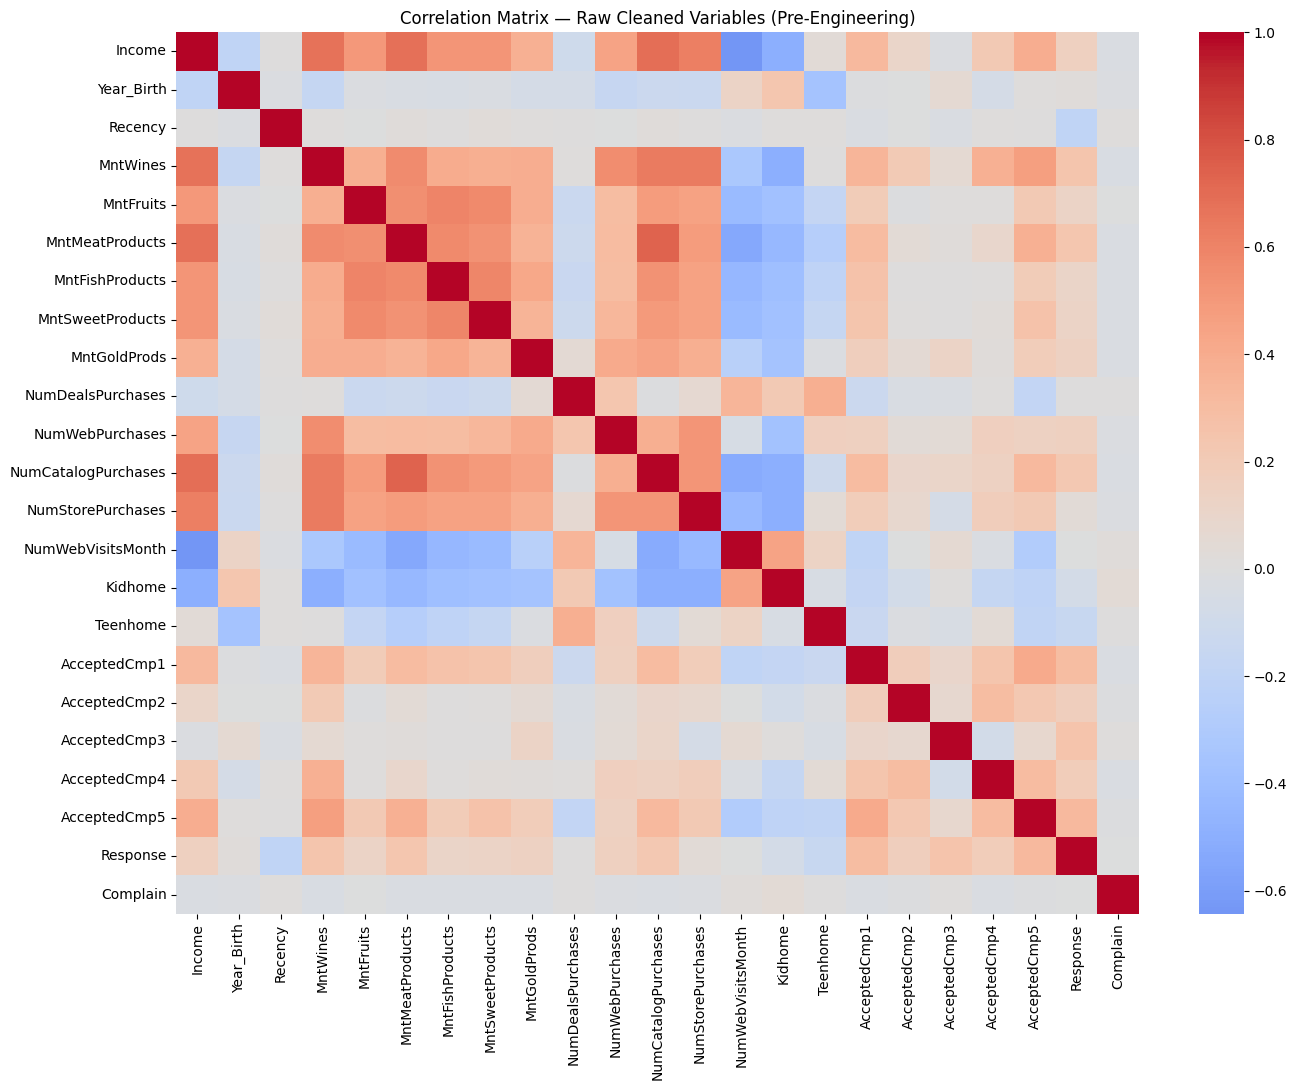

In [12]:
raw_corr_cols = [
    "Income", "Year_Birth", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Kidhome", "Teenhome",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain",
]
raw_corr = df[raw_corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(raw_corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Raw Cleaned Variables (Pre-Engineering)")
plt.tight_layout()
plt.show()


### Feature Rationale

Reviewing the correlation heatmap above, each engineered feature responds to a specific pattern in the raw data:

- **`Age`** — date arithmetic on `Year_Birth`. Raw `Year_Birth` is hard to interpret at a glance and drifts every calendar year; **`Age`** is the stable, directly meaningful version.
- **`Total_Spending`** — aggregation (sum) of the six `MntWines`…`MntGoldProds` columns (`config.SPEND_COLS`). They're tightly, uniformly positively correlated with each other on the heatmap (solid mid-to-dark red block) and each right-skewed at very different scales (see [Univariate Distributions](#Numeric)) — collapsing them into one **`Total_Spending`** aggregate avoids feeding six correlated, differently-scaled dimensions into a distance-based model.
- **`TotalNo_Children`** — aggregation (sum) of `Kidhome` + `Teenhome`, computed for exploration alongside the two raw columns. `Kidhome` is strongly negatively correlated with `Income` and every `Mnt*` column, and positively correlated with `NumWebVisitsMonth`; `Teenhome`, by contrast, shows only weak correlations across the board. The two don't behave alike, so **`TotalNo_Children`** blends a strong signal with a near-neutral one rather than capturing one consistent effect.
- **`Total_Campaigns_Accepted`** — aggregation (sum) of `AcceptedCmp1`–`5` and `Response` (`config.ACCEPTED_CMP_COLS`). These six flags correlate with each other only mildly on the heatmap (light red, not the tight block the `Mnt*` columns show) — summing them into **`Total_Campaigns_Accepted`** is still a reasonable single marketing-responsiveness signal, but expect a noisier aggregate than `Total_Spending`.
- **`Avg_Spend_Per_Purchase`** — a ratio: `Total_Spending` divided by total purchases across all four purchase channels (`config.PURCHASE_COUNT_COLS`), i.e. average basket size rather than total volume. Guarded against divide-by-zero — customers with zero purchases get `0.0` rather than `NaN`/`inf`. Spend and purchase counts move together on the heatmap but aren't identical, so **`Avg_Spend_Per_Purchase`** tests whether basket size adds information the two raw signals don't already cover on their own.
- **`Customer_Tenure`** — date arithmetic (days since `Dt_Customer`), how long someone has been a customer.

Two more patterns from the heatmap are worth noting even though they don't motivate a new engineered feature: `NumCatalogPurchases` is strongly correlated with both `Income` and `MntMeatProducts` specifically, while `NumDealsPurchases` is essentially uncorrelated with everything — the two raw purchase-count columns behave very differently despite both being purchase channels. `Recency` and `Year_Birth` are also essentially uncorrelated with everything else — each carries independent information rather than duplicating a signal already present elsewhere.

**Considered and rejected:** binning `Age`/`Income`/`Customer_Tenure` into ordinal buckets. K-Means handles continuous numerics natively — binning would only throw away resolution it can already use. The real unordered-categorical problem (`Education`/`Marital_Status`) is a different case entirely.

In [13]:
df = engineer_features(df)
engineered_cols = [
    'Age', 'Total_Spending', 'TotalNo_Children',
    'Total_Campaigns_Accepted', 'Avg_Spend_Per_Purchase', 'Customer_Tenure',
]
df[engineered_cols].head()

,Age,Total_Spending,TotalNo_Children,Total_Campaigns_Accepted,Avg_Spend_Per_Purchase,Customer_Tenure
0,69,1617,0,1,64.680000,5102
1,72,27,2,0,4.500000,4552
2,61,776,0,0,36.952381,4751
3,42,53,1,0,6.625000,4578
4,45,422,1,0,22.210526,4600


## Feature Selection

Each candidate below — every cleaned + engineered column in `corr_cols` — is evaluated with two kinds of evidence, ending in an explicit include/exclude call: **statistical** (its correlation with the rest of the candidate pool, and — where correlation alone doesn't settle it — a direct silhouette comparison with and without the feature) and **business** (whether the resulting axis is something the [Business Goal](#Business-Goal) can actually act on, e.g. a channel a marketer can target separately, or a construct like income that means something different from the spend it correlates with).

Correlation with `Income`/`Total_Spending` comes up often below without being disqualifying on its own — this is a clustering project, not a regression, so there's no target for a correlated feature to bias against. What it can still do is skew a Euclidean-distance algorithm like K-Means, so it's treated as a diagnostic to check empirically (via silhouette), not a threshold to fail.

The candidates are worked through one at a time below, each ending in its own decision, with a summary of the resulting feature set at the end.

### Correlation Setup

Every cleaned + engineered column, computed once as `corr` and reused throughout this section. The raw-column clustering picture (e.g. the `Mnt*` block) is already shown in [Feature Rationale](#Feature-Rationale) above — no need to redraw the same heatmap with six more engineered rows added when each of those rows gets its own bar chart below instead.

In [14]:
corr_cols = [
    "Income", "Age", "Recency", "Total_Spending",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Kidhome", "Teenhome", "TotalNo_Children", "Customer_Tenure", "Total_Campaigns_Accepted", "Avg_Spend_Per_Purchase",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain",
]
# Year_Birth left out -- Age is just Year_Birth flipped around, so of course
# they're near-perfectly correlated. Not a real pattern, just math.
corr = df[corr_cols].corr()


In [15]:
def plot_corr_bar(feature, figsize=(6, 4)):
    """
    Horizontal bar chart of one feature's correlation with every other
    column in corr_cols, sorted by value. Easier to scan for the 2-3
    relationships that actually matter than reading across a wide table --
    the full corr_cols x corr_cols matrix is already shown once above.
    """
    row = corr.loc[feature, [c for c in corr_cols if c != feature]].sort_values()
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in row]
    plt.figure(figsize=figsize)
    row.plot.barh(color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"{feature} vs. every other candidate")
    plt.xlabel("Pearson r")
    plt.tight_layout()
    plt.show()


### Demographics (Age, Teenhome, Kidhome, TotalNo_Children)

Who the customer is, independent of what they buy or how they engage — age and household composition.

#### Age

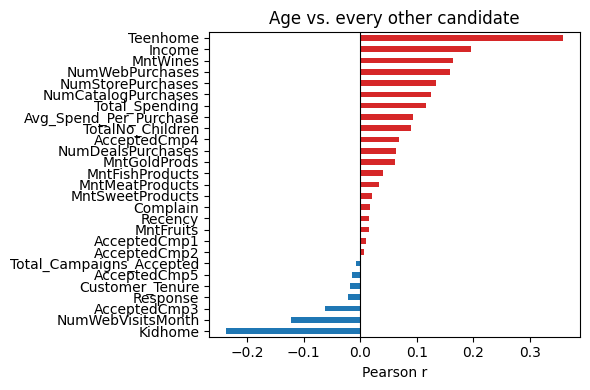

In [16]:
plot_corr_bar("Age")


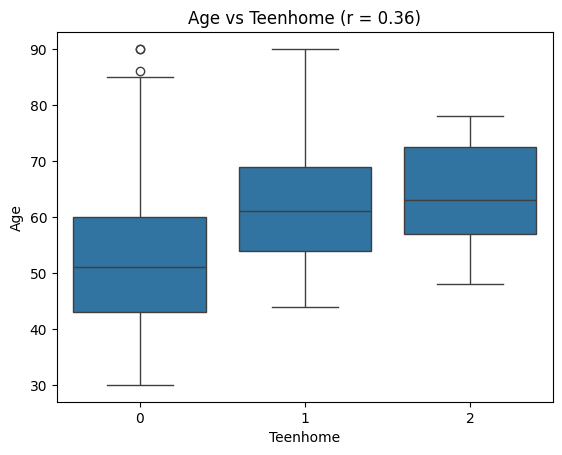

In [17]:
sns.boxplot(x=df["Teenhome"], y=df["Age"])
r = df[["Age", "Teenhome"]].corr().iloc[0, 1]
plt.title(f"Age vs Teenhome (r = {r:.2f})")
plt.show()


**Decision: Included.**

**Statistical:** shows no meaningful correlation with spending or shopping behavior. Its only notable relationship is a moderate positive correlation with `Teenhome` (r ≈ 0.36) — older customers are more likely to have teenagers than toddlers, a natural life-stage pattern rather than one feature quietly duplicating another.

**Business:** age is one of the few levers a marketer can act on directly and cheaply (e.g. retirement-related offers, different messaging by generation) without needing behavioral history to already exist for a customer, which matters for new sign-ups.

#### Teenhome

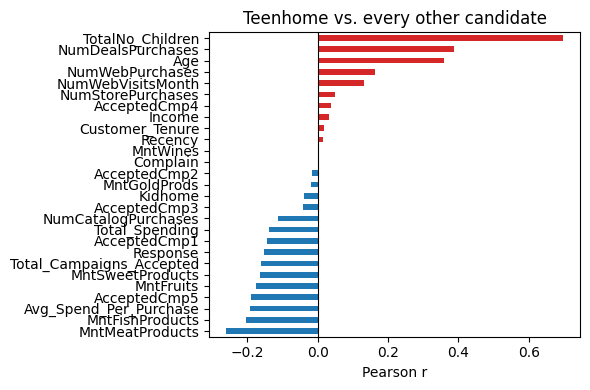

In [18]:
plot_corr_bar("Teenhome")


**Statistical:** weakly correlated with `Income`/`Total_Spending`/the purchase columns (|r| ≤ 0.16), unlike `Kidhome`. Its real ties are `Age` (r ≈ 0.36, already selected) and `TotalNo_Children` (r ≈ 0.70, by construction). Correlation alone can't settle it against `Kidhome`/`TotalNo_Children`, so it's decided empirically — silhouette score with each option added to the rest of the feature set:

In [19]:
def paired_silhouette_delta(base_cols, extra_cols, seeds=(0, 1, 2, 3, 4)):
    """
    For each seed, fit the pipeline with and without extra_cols added to
    base_cols, using that SAME seed on both sides, then take the difference.
    Pairing the fits this way cancels out centroid-initialization noise far
    better than comparing two independent single-run silhouette scores would
    -- the same logic check_cluster_stability() applies to overall cluster
    stability, applied here to one feature (or feature combo) at a time.
    """
    deltas = []
    for seed in seeds:
        _, _, sil_base = fit_pipeline(
            df[base_cols].copy(), n_clusters=config.N_CLUSTERS, random_state=seed
        )
        _, _, sil_extra = fit_pipeline(
            df[base_cols + extra_cols].copy(), n_clusters=config.N_CLUSTERS, random_state=seed
        )
        deltas.append(sil_extra - sil_base)
    return pd.Series(deltas, index=seeds)


selected_features = [
    "Age", "Income", "Recency", "Customer_Tenure", "Total_Spending",
    "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "NumDealsPurchases",
]

household_options = {
    "Kidhome": ["Kidhome"],
    "Teenhome": ["Teenhome"],
    "TotalNo_Children": ["TotalNo_Children"],
    "Kidhome + Teenhome": ["Kidhome", "Teenhome"],
}
household_deltas = pd.DataFrame({
    name: paired_silhouette_delta(selected_features, extra)
    for name, extra in household_options.items()
})
household_deltas.agg(["mean", "std"]).T.rename(columns={"mean": "mean_delta", "std": "std_delta"})


,mean_delta,std_delta
Kidhome,0.014175,0.000779
Teenhome,0.035926,0.000116
TotalNo_Children,0.002290,0.000677
Kidhome + Teenhome,0.031446,0.000116


**Decision: Included.**

`Teenhome` alone gives the largest, most stable lift — mean Δsilhouette +0.0359 across 5 seeds, standard deviation just 0.0001, so this is a real effect, not noise. `Kidhome` alone helps too (+0.0142), `TotalNo_Children` barely clears its own noise floor (+0.0023 vs. std 0.0006), and `Kidhome` + `Teenhome` together (+0.0314) is a bit less than `Teenhome` alone — consistent with `Kidhome` re-adding a signal (`Income`/`Total_Spending`) already in the model. Silhouette alone would pick `Teenhome` only.

**Business:** but that's not the whole story. With `Teenhome` alone, a childless household and one with only young children both read as `Teenhome = 0` — indistinguishable, even though "young family" is a highly actionable life-stage segment in retail (different categories, different price sensitivity, high growth potential). Adding `Kidhome` back costs just 0.0045 mean silhouette (about 13% relative) to recover that distinction — a small, well-measured price for a segment boundary worth keeping. See [Kidhome](#Kidhome) below.

#### Kidhome

**Decision: Included.**

**Statistical:** correlates most strongly with `Income` (r ≈ -0.51) and `Total_Spending` (r ≈ -0.56) — the same magnitude treated as disqualifying for `Avg_Spend_Per_Purchase` below. Added on top of `Teenhome`, it costs a small, precisely-measured amount of cluster separation (+0.0314 vs. +0.0359 for `Teenhome` alone — see the [Teenhome comparison](#Teenhome)).

**Business:** that small cost buys back a distinction `Teenhome` alone can't make: childless vs. young-family households. Life-stage segmentation routinely splits on exactly this, and losing that boundary to save a fraction of a silhouette point would hide a commercially relevant group from the [Business Goal](#Business-Goal)'s target audience.

#### TotalNo_Children (Kidhome + Teenhome)

**Decision: Excluded.**

**Statistical:** the aggregate barely clears its own noise floor — mean Δ +0.0023 vs. std 0.0006 (see the [Teenhome comparison](#Teenhome)), about six times smaller than `Teenhome`'s effect alone. It blends `Teenhome`'s real signal with `Kidhome`'s redundant one, diluting rather than combining. With both raw columns already selected individually, `TotalNo_Children` is just their sum — redundant on top of redundant.

**Business:** the two raw columns already distinguish "young family," "family with teens," and "no kids at home"; collapsing them into one count throws that distinction away. Still computed for exploration (e.g. [Cluster Profile](#Cluster-Profile)), just not in `config.FEATURES`.

### Monetary Value (Income, Total_Spending, Avg_Spend_Per_Purchase)

How much the customer is worth, in three related but distinct forms: earning capacity, actual spend, and spend intensity per purchase.

#### Income

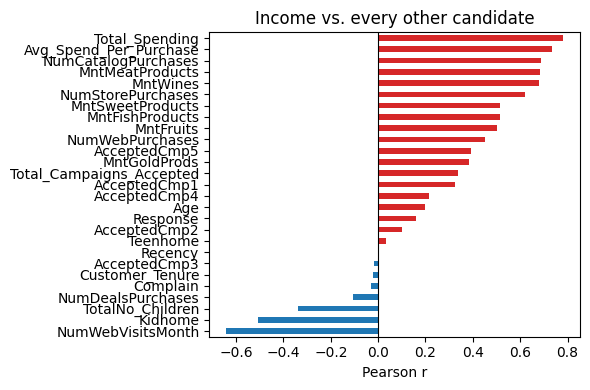

In [20]:
plot_corr_bar("Income")


**Decision: Included.**

**Statistical:** highly correlated with `Total_Spending` (r ≈ 0.78) and `NumCatalogPurchases` (r ≈ 0.69) — as strong as correlations that get other candidates excluded below. The difference is what it represents, not the r-value.

**Business:** the only earning-capacity signal in the model — every other value feature measures what a customer actually bought, not what they could afford. Without `Income`, two customers with the same `Total_Spending` look identical to the model, even if one is a high earner spending modestly and the other is a low earner stretching their budget — very different customers for a loyalty/upsell read. Kept despite the correlation.

#### Total_Spending

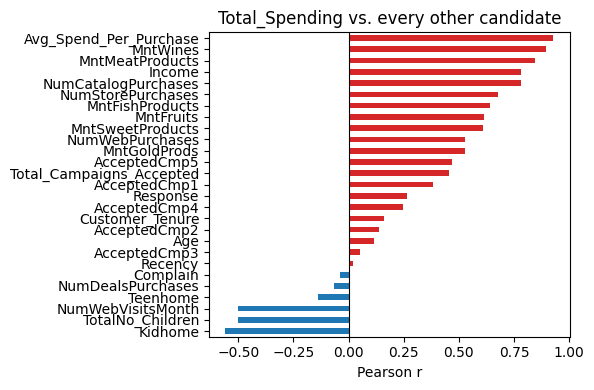

In [21]:
plot_corr_bar("Total_Spending")


**Decision: Included.**

**Statistical:** the single most connected column in the candidate pool. Its strongest tie is `Avg_Spend_Per_Purchase` (r ≈ 0.93, excluded below), followed by the six raw `Mnt*` columns it aggregates (r ≈ 0.53–0.89 each, see the [Feature Rationale](#Feature-Rationale) heatmap), then `Income` (r ≈ 0.78), `NumCatalogPurchases` (r ≈ 0.78, also included), and `NumStorePurchases`/`NumWebPurchases` (r ≈ 0.68/0.53, both included). None of that is a red flag here: `Total_Spending` *is* the value axis this feature set is built around, so everything spend-adjacent correlates with it — the same logic that keeps `Income`, `NumStorePurchases`, `NumWebPurchases`, and `NumCatalogPurchases` despite correlating back with it.

**Business:** the core value metric the [Business Goal](#Business-Goal) is built around — loyalty/upsell targeting starts with how much a customer spends. Without it, a segment has no obvious answer to "how much does this customer matter to the business," which is the first thing a marketer needs in order to prioritize between segments.

#### Avg_Spend_Per_Purchase

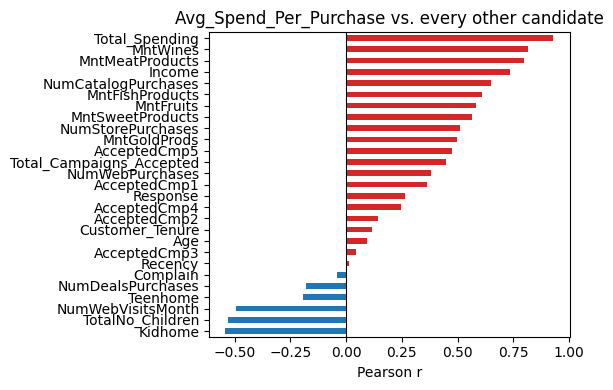

In [22]:
plot_corr_bar("Avg_Spend_Per_Purchase")


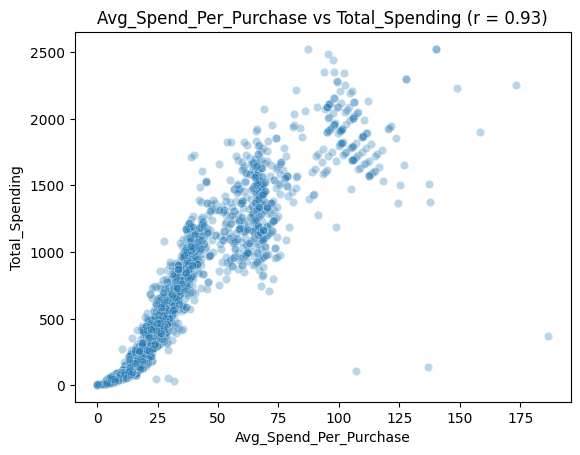

In [23]:
sns.scatterplot(x=df["Avg_Spend_Per_Purchase"], y=df["Total_Spending"], alpha=0.3)
r = df[["Avg_Spend_Per_Purchase", "Total_Spending"]].corr().iloc[0, 1]
plt.title(f"Avg_Spend_Per_Purchase vs Total_Spending (r = {r:.2f})")
plt.show()


In [24]:
confirmed = selected_features + ["Teenhome", "Kidhome"]
avg_spend_deltas = paired_silhouette_delta(confirmed, ["Avg_Spend_Per_Purchase"])
avg_spend_deltas.agg(["mean", "std"])


mean    0.000668
std     0.000126
dtype: float64

**Decision: Excluded.**

**Statistical:** r ≈ 0.93 with `Total_Spending` — the strongest pairwise correlation in the candidate pool — confirmed by a tight, near-linear scatter, with only a few high-spend outliers (customers whose spend is concentrated in unusually few purchases) breaking the line. Beyond that, it tracks essentially the same columns `Total_Spending` already does, at roughly the same strength: `MntWines` (r ≈ 0.85), `MntMeatProducts` (r ≈ 0.78), `Income` (r ≈ 0.72), `NumCatalogPurchases` (r ≈ 0.65) on the positive side; `Kidhome` (r ≈ -0.55), `TotalNo_Children` (r ≈ -0.50, excluded above), `NumWebVisitsMonth` (r ≈ -0.48, also included) on the negative — the same value/family-size/browsing pattern already covered by the selected features, not a distinct one. The paired silhouette check confirms it: mean Δ +0.0007 across 5 seeds, std 0.0001 — every seed positive, so not noise, but about fifty times smaller than `Teenhome`'s effect. The correlation is the actual reason to exclude it; the silhouette check just confirms there's no upside being missed.

**Business:** average basket size sounds like a distinct behavior, but its correlation profile is `Total_Spending`'s profile restated at a different scale — built directly from `Total_Spending` and purchase counts, it's a rescaling, not a new axis a marketer could act on.

### Recency, Tenure & Complaints (Recency, Customer_Tenure, Complain)

Time-based engagement signals — how recently and how long a customer has been active, plus the one explicit satisfaction signal in the dataset.

#### Recency

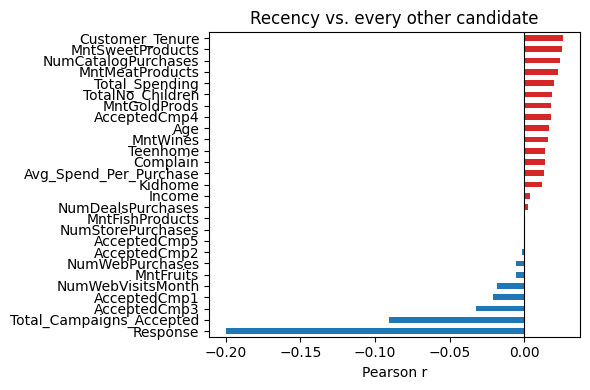

In [25]:
plot_corr_bar("Recency")


**Statistical:** virtually uncorrelated with every other candidate (|r| ≤ 0.03), aside from two potential leakage columns — `Response` (r ≈ -0.20) and `Total_Campaigns_Accepted` (r ≈ -0.09, see below) — an expected tie, since a customer who bought recently is more likely to have "responded" to whatever campaign ran most recently. That only shows `Recency` isn't redundant, though — `Complain` is even cleaner (max |r| ≈ 0.04), so a clean correlation profile alone doesn't earn a feature its place here.

**Business:** the [Business Goal](#Business-Goal) explicitly calls for win-back campaigns targeting inactive customers, and "inactive" is fundamentally a time-based idea — days since last purchase — that no other feature captures. A customer who spent heavily two years ago and then vanished can look identical to a big current spender on every other feature (`Total_Spending`, `Income`, purchase counts); `Recency` is the one signal that tells them apart, which decides whether that customer gets a win-back offer at all.

#### Customer_Tenure

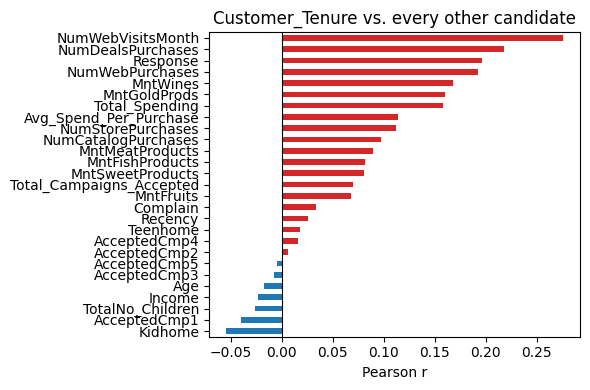

In [26]:
plot_corr_bar("Customer_Tenure")


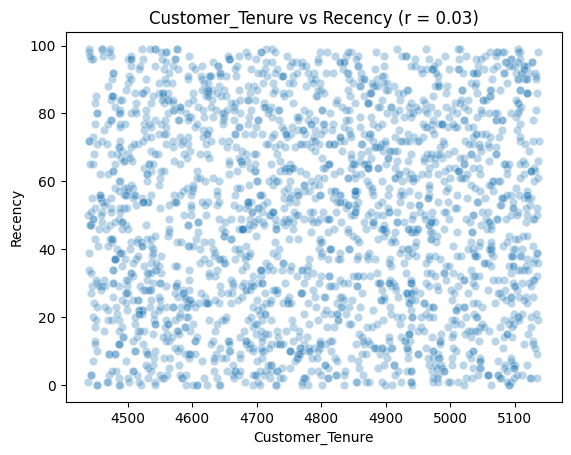

In [27]:
sns.scatterplot(x=df["Customer_Tenure"], y=df["Recency"], alpha=0.3)
r = df[["Customer_Tenure", "Recency"]].corr().iloc[0, 1]
plt.title(f"Customer_Tenure vs Recency (r = {r:.2f})")
plt.show()


**Decision: Included.**

**Statistical:** has a few moderate correlations — `NumWebVisitsMonth` (r ≈ 0.28), `NumDealsPurchases` (r ≈ 0.22), `NumWebPurchases` (r ≈ 0.19) — but none strong enough to call it a duplicate of any one feature (compare `Income` vs. `Total_Spending` at r ≈ 0.78, which *is* redundant). More importantly, it's nearly uncorrelated with `Recency` itself (r ≈ 0.03, confirmed flat in the scatter above) — the comparison that matters most, since the business case below depends on tenure and recency measuring different things.

**Business:** tenure and recency answer different questions — a long-tenure customer gone quiet needs a win-back; a brand-new customer gone quiet was never onboarded properly. `Recency` alone can't tell those two apart.

#### Complain

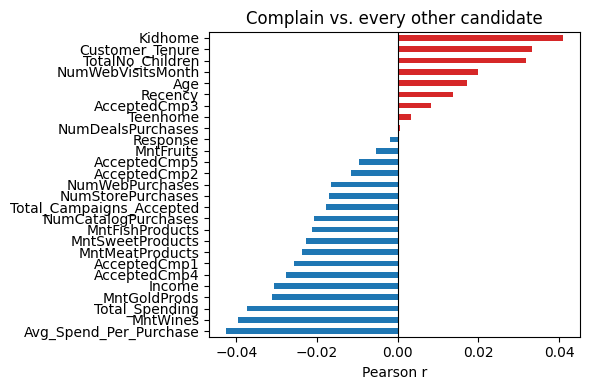

In [28]:
plot_corr_bar("Complain")


**Decision: Excluded.**

**Statistical:** not a correlation question — 21 of 2,216 rows are 1, near-zero variance regardless of what it correlates with. For the record, the correlation profile is about as clean as any candidate in this dataset — every tie is under |r| ≈ 0.04 (`Kidhome` r ≈ 0.04, `Avg_Spend_Per_Purchase` r ≈ -0.04, `MntWines`/`Total_Spending` r ≈ -0.03 to -0.04) — even cleaner than `Recency`'s own profile (see the [Recency](#Recency) note above). That cleanliness doesn't earn it a place here: variance, not correlation, is the disqualifying fact.

**Business:** too rare (0.9% positive rate — see [Univariate Distributions](#Numeric)) to separate customers into meaningful groups, and complaint handling is already a separate operational process, not a segmentation input.

### Purchase Channel (NumWebPurchases, NumWebVisitsMonth, NumStorePurchases, NumCatalogPurchases)

Where and how often the customer buys, across every channel this dataset tracks — web, browsing-without-buying, store, and catalog.

#### NumWebPurchases

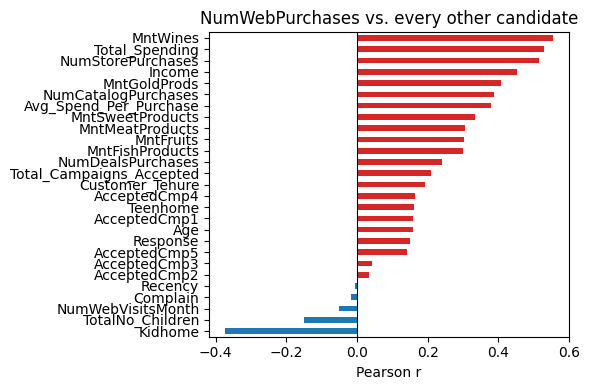

In [29]:
plot_corr_bar("NumWebPurchases")


**Decision: Included.**

**Statistical:** sits in the same spend/value cluster as everything else in this dataset — `MntWines` (r ≈ 0.55), `Total_Spending` (r ≈ 0.53), `NumStorePurchases` (r ≈ 0.50), `Income` (r ≈ 0.45) — and about as strongly as `NumCatalogPurchases` (r ≈ 0.40, also included), so the correlation profile alone doesn't distinguish it from that feature either. Also negatively tied to `Kidhome` (r ≈ -0.37): households with kids buy less online, the same pattern `Total_Spending` and `Income` already show against `Kidhome`.

**Business:** one of the two channel-share columns the [Business Goal](#Business-Goal) needs for web-vs-store targeting — a channel signal, not a value signal, even though it moves with value. The correlation with spend is the cost of a feature the use case requires.

#### NumWebVisitsMonth

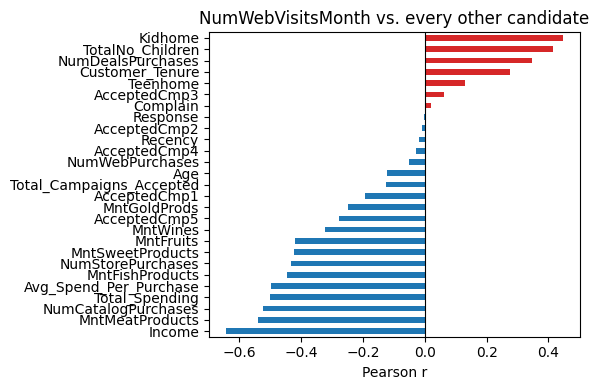

In [30]:
plot_corr_bar("NumWebVisitsMonth")


**Decision: Included.**

**Statistical:** the strongest correlations of any candidate in the pool, and almost entirely negative — `Income` (r ≈ -0.62), `MntMeatProducts` (r ≈ -0.55), `NumCatalogPurchases` (r ≈ -0.52, also included), `Total_Spending` (r ≈ -0.50), `Avg_Spend_Per_Purchase` (r ≈ -0.48, excluded above): more browsing goes with less buying, across essentially every value column at once. The positive side tells a consistent story rather than adding noise — `Kidhome` (r ≈ 0.45), `TotalNo_Children` (r ≈ 0.42, excluded above), `NumDealsPurchases` (r ≈ 0.35, also included), `Customer_Tenure` (r ≈ 0.28) — browses more, spends less, has kids, hunts for deals.

**Business:** that inverse relationship flags a distinct customer type — heavy browsing without converting — a retargeting case none of the spend or purchase-count features can see on their own. Its tie to `NumDealsPurchases` is the same deal-seeking household profile, seen through a different channel — reinforcing, not duplicating, that signal.

#### NumStorePurchases

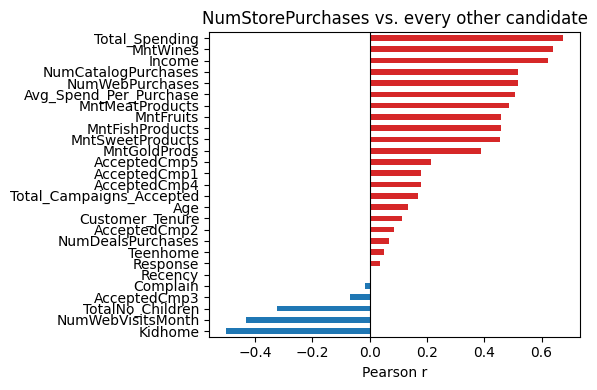

In [31]:
plot_corr_bar("NumStorePurchases")


**Decision: Included.**

**Statistical:** r ≈ 0.62 with `Income`, 0.68 with `Total_Spending`, 0.52 with `NumCatalogPurchases` — as strong as the correlation that gets `Avg_Spend_Per_Purchase` excluded above.

**Business:** the other half of the web-vs-store channel split the segmentation is built to support, not a redundant rescaling of spend.

#### NumCatalogPurchases

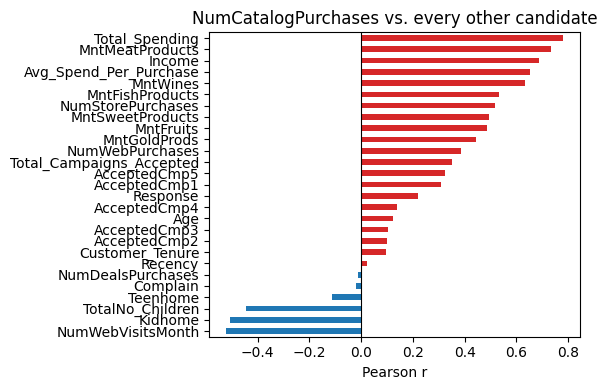

In [32]:
plot_corr_bar("NumCatalogPurchases")


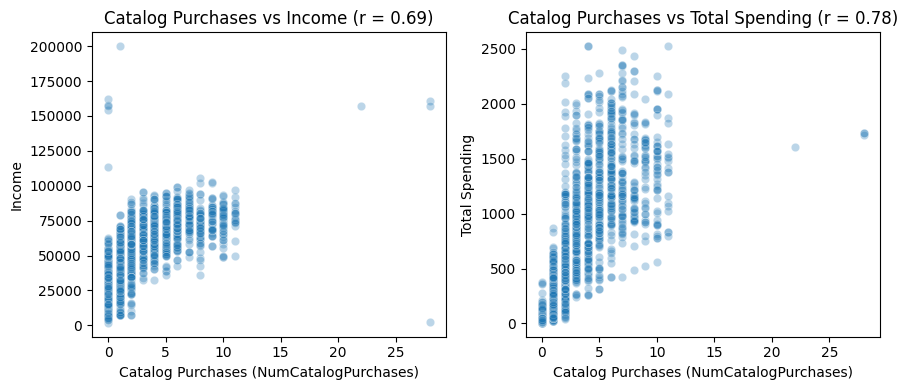

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, y in zip(axes, ["Income", "Total_Spending"]):
    sns.scatterplot(x=df["NumCatalogPurchases"], y=df[y], alpha=0.3, ax=ax)
    r = df[["NumCatalogPurchases", y]].corr().iloc[0, 1]
    ax.set_title(f"Catalog Purchases vs {y.replace('_', ' ')} (r = {r:.2f})")
    ax.set_xlabel("Catalog Purchases (NumCatalogPurchases)")
    ax.set_ylabel(y.replace('_', ' '))
plt.tight_layout()
plt.show()


In [34]:
catalog_deltas = paired_silhouette_delta(confirmed, ["NumCatalogPurchases"])
catalog_deltas.agg(["mean", "std"])


mean   -0.004870
std     0.000372
dtype: float64

**Decision: Included.**

**Statistical:** correlates most strongly with `Total_Spending` (r ≈ 0.78), `MntMeatProducts` (r ≈ 0.75), and `Income` (r ≈ 0.69) — comparable to correlations already accepted elsewhere (`Income` r ≈ 0.78 with `Total_Spending`, `NumStorePurchases` r ≈ 0.68), so the correlation strength alone isn't a clean reason to cut it either. A channel-share check (each channel's purchases as a fraction of total purchases) shows why catalog is harder to separate from wealth than web/store: web share correlates only r ≈ -0.22/-0.20 with `Income`/`Total_Spending`, store share r ≈ -0.37/-0.44, but catalog share still r ≈ 0.58/0.66. The scatter against `Income` and `Total_Spending` adds a detail the correlation number misses, though: purchases plateau around 10–11 per customer well before income or spend does — aside from two extreme outliers around 22 and 28 purchases — a ceiling pure wealth-riding wouldn't produce. The paired silhouette check is negative (mean Δ -0.0049, std 0.0003, every seed), so K-Means doesn't reward adding it — the case for keeping it is business, not statistical.

**Business:** it names a real, distinct shopping channel, on par with web and store, and that's reason enough to keep it even though the silhouette check argues against it and the [Business Goal](#Business-Goal) doesn't spell out catalog targeting the way it does the web-vs-store split. A mail-order/catalog channel is exactly the kind of behavior a segmentation should be able to surface on its own rather than leaving folded into `Income` and `Total_Spending`. Included despite the correlation and the silhouette cost — the same call already made for `Income`.

### Promotion Responsiveness (NumDealsPurchases, Total_Campaigns_Accepted / AcceptedCmp1–5 / Response)

How the customer responds to discounts and marketing campaigns.

#### NumDealsPurchases

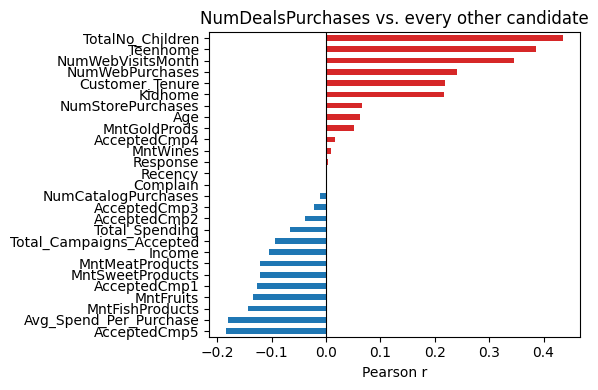

In [35]:
plot_corr_bar("NumDealsPurchases")


**Decision: Included.**

**Statistical:** its clearest ties are household composition and browsing, not value — `TotalNo_Children` (r ≈ 0.43, excluded above), `Teenhome` (r ≈ 0.38, also included), `NumWebVisitsMonth` (r ≈ 0.33, also included) — a consistent deal-seeking, browsing, larger-household profile rather than three unrelated signals. Only weakly tied to `Income` (r ≈ -0.11) and `Total_Spending` (r ≈ -0.08) — genuinely not a value proxy, unlike almost every other purchase-count column.

**Business:** the continuous promotion-responsiveness signal the segmentation needs. Deliberately not built from `AcceptedCmp1`–`5`/`Response` (see `Total_Campaigns_Accepted` below), which are outcomes of specific past campaigns and would leak old targeting into new segments.

#### Total_Campaigns_Accepted (and AcceptedCmp1–5 / Response)

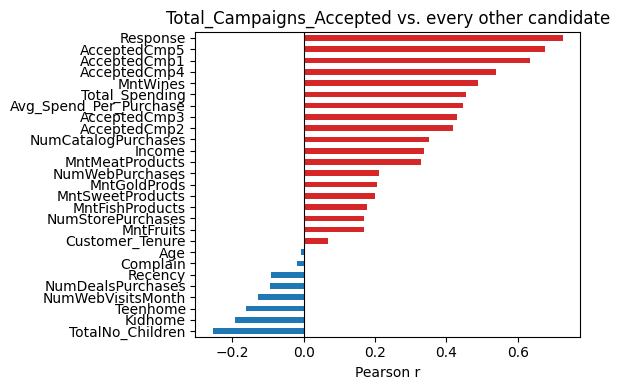

In [36]:
plot_corr_bar("Total_Campaigns_Accepted")


**Decision: Excluded.**

**Statistical:** correlates most strongly with the columns it's built from — `Response` (r ≈ 0.72), `AcceptedCmp5` (r ≈ 0.67), `AcceptedCmp1` (r ≈ 0.63), `AcceptedCmp4` (r ≈ 0.53), and the rest of `config.ACCEPTED_CMP_COLS` close behind — unsurprising since it's literally their sum. Beyond that it's only moderately tied to the spend/value cluster (`MntWines` r ≈ 0.48, `Total_Spending` r ≈ 0.45, `Avg_Spend_Per_Purchase` r ≈ 0.42, excluded above, `Income` r ≈ 0.34) and weakly negative with household size (`TotalNo_Children` r ≈ -0.27, `Kidhome` r ≈ -0.20) — none of that is the deciding factor either way.

**Business:** the one candidate where business logic overrides the statistics outright. Its strongest correlations are exactly what should raise suspicion, not confidence — they come from the `AcceptedCmp1`–`5`/`Response` columns it aggregates, and those record whether a customer took up specific *past* campaigns — outcomes of prior targeting, not stable traits. Clustering on them would leak old targeting into the segments used to make new targeting decisions.

#### Education, Marital_Status

**Decision: Excluded.**

**Statistical:** neither is directly usable — K-Means needs numeric distances. `Marital_Status` is genuinely nominal (no natural order among `Married`/`Together`/`Single`/`Divorced`/`Widow`), so one-hot-encoding is the only honest representation, and that would add several low-signal dimensions relative to the behavioral/value features already selected. `Education` is different: it has a real order (`Basic` < `2n Cycle` < `Graduation` < `Master` < `PhD`), so an ordinal encoding is a legitimate option here in a way it isn't for `Marital_Status` — worth reconsidering if a future iteration wants an education-level axis without paying the one-hot dimensionality cost.

**Business:** plausibly useful demographic detail, but neither feeds the model as-is. Adding `Education` as an ordinal feature would still need the same correlation-then-business-case process every other candidate in this section went through — e.g. checking it against `Income`/`Total_Spending` first. The `Marital_Status` data-quality issue ([Multi-Categorical](#Multi-Categorical): `Alone`/`Absurd`/`YOLO`) doesn't affect this analysis, but is worth noting in case a one-hot-encoded version is added later.


(The correlation figures above are backed by the per-feature bar charts and scatter/boxplots in each subsection, and the [Feature Rationale](#Feature-Rationale) heatmap for the raw-column clustering pattern — rerun them if you want to sanity-check after a data refresh.)

### Resulting Feature Set

Twelve features survive both the statistical and business case above: `Age`, `Income`, `Recency`, `Customer_Tenure`, `Total_Spending`, `NumWebPurchases`, `NumStorePurchases`, `NumCatalogPurchases`, `NumWebVisitsMonth`, `NumDealsPurchases`, `Teenhome`, `Kidhome`. Five of them — `Income`, `NumStorePurchases`, `NumWebPurchases`, `NumCatalogPurchases`, and `Kidhome` — are kept despite correlation or silhouette evidence that, treated as a mechanical cutoff, would have excluded them the same way it excluded `Avg_Spend_Per_Purchase` and `Total_Campaigns_Accepted`; the business case documented next to each is what makes the difference, not the r-value or the silhouette number alone. `NumCatalogPurchases` is the clearest case of this: its paired silhouette check is negative, yet it's kept purely because a catalog/mail-order channel is a real, distinct behavior the [Business Goal](#Business-Goal) should be able to see. `config.FEATURES` has been updated to this list.

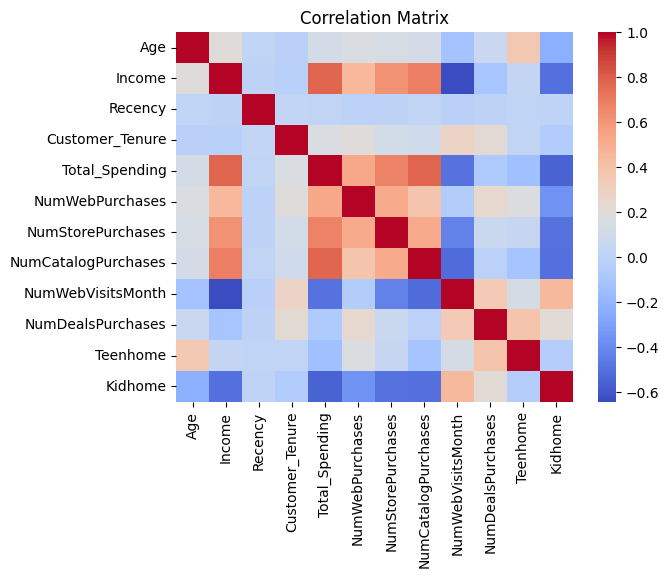

In [37]:
corr = df[config.FEATURES].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


No off-diagonal cell here approaches the ≈ 0.93 that got `Avg_Spend_Per_Purchase` excluded in Feature Selection above — the strongest ties visible (the `Total_Spending` / `NumCatalogPurchases` / `Income` / `NumStorePurchases` block, and `Kidhome`'s broad negative row/column) are the same correlations already reviewed and justified feature-by-feature above, just shown together in one picture. K-Means clusters on distance, not a regression target, so correlation isn't disqualifying by itself — every one of these ties was already checked individually (via silhouette, where correlation alone didn't settle it) before being kept, and `StandardScaler` puts every feature on the same scale before fitting, so no correlated block can dominate distance purely by unit size. Safe to proceed to modeling with this set.


## Model Training

Everything from here on operates on the twelve features selected above (`config.FEATURES`). First pick `k` — the number of clusters K-Means will split customers into. Then run two experiments that both use that `k`: a baseline (`StandardScaler` -> `KMeans`) and a variant that adds a `PCA` step between them, compare the two on silhouette and stability, and fit/save whichever one wins as the single production artifact.

### Choosing the Number of Clusters (K)

The elbow method alone is subjective. `evaluate_k_range()` fits a full **scaler -> KMeans pipeline** for each candidate k (not just a bare `KMeans`), so this loop exercises exactly the same code path as final training — and also records the **silhouette score**, which gives a defensible, numeric basis for the final choice rather than eyeballing a bend in a curve.


In [38]:
X = df[config.FEATURES].copy()

# evaluate_k_range takes the RAW feature matrix — each candidate k fits its
# own scaler->KMeans pipeline internally, mirroring final training exactly.
k_results = evaluate_k_range(X)
k_df = pd.DataFrame(k_results).T.round(3)
k_df

,inertia,silhouette
2,19005.724,0.267
3,16486.473,0.230
4,15122.026,0.183
5,14115.099,0.180
6,13471.665,0.170
7,12925.646,0.159
8,12484.880,0.140
9,12093.222,0.137


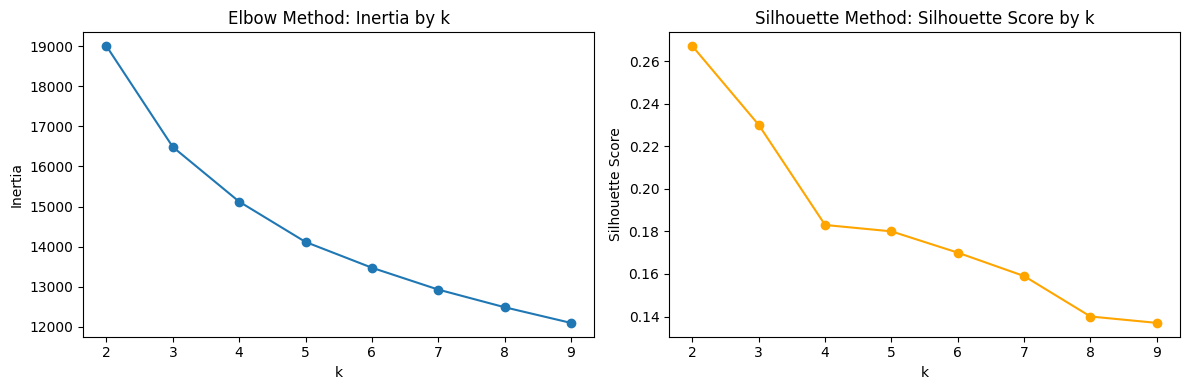

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_df.index, k_df['inertia'], marker='o')
axes[0].set_title('Elbow Method: Inertia by k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_df.index, k_df['silhouette'], marker='o', color='orange')
axes[1].set_title('Silhouette Method: Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


In [40]:
labels_k4 = fit_pipeline(X, n_clusters=4)[1]
labels_k5 = fit_pipeline(X, n_clusters=5)[1]

cols = ["NumDealsPurchases", "Income", "Total_Spending"]

profile_k4 = cluster_profile(df, labels_k4)[cols]
profile_k4["n"] = pd.Series(labels_k4).value_counts().sort_index()
print("k=4 cluster profile (selected columns):")
print(profile_k4.round(2))

profile_k5 = cluster_profile(df, labels_k5)[cols]
profile_k5["n"] = pd.Series(labels_k5).value_counts().sort_index()
print("\nk=5 cluster profile (selected columns):")
print(profile_k5.round(2))


k=4 cluster profile (selected columns):
         NumDealsPurchases    Income  Total_Spending    n
Cluster                                                  
0                     2.40  41995.33          119.91  523
1                     1.14  77353.46         1368.17  532
2                     1.97  29649.36          111.77  571
3                     3.67  59776.04          832.00  590

k=5 cluster profile (selected columns):
         NumDealsPurchases    Income  Total_Spending    n
Cluster                                                  
0                     6.49  48386.71          491.95  196
1                     1.98  41200.66           99.70  452
2                     1.08  78285.08         1385.18  498
3                     2.83  61526.89          882.53  523
4                     1.77  29327.63           95.82  547


Silhouette peaks at k=2 (0.267) and declines monotonically through k=9 — no local bump at k=5. The inertia elbow is early too: the marginal drop from k=4→5 is -1,007, falling further to -643 from k=5→6 and continuing to shrink after that — the steepest gains are already captured by k=4, making it the more defensible pick on the curves alone.

So on the numbers, k=4 wins (k=2 even more so). But k=2 is too coarse to act on — the [Business Goal](#Business-Goal) needs to tell loyalty/upsell, win-back, and channel-specific customers apart, and a two-way split can't do that. k=4 vs. k=5 comes down to one question: does the extra cluster reveal something k=4 hides? Yes — at k=4, deal-seeking customers are buried inside a larger, lower-income, teen-family group (`NumDealsPurchases` ≈ 2.4). At k=5, that group splits and a distinct **Deal-Seeking Large Families** segment emerges (`NumDealsPurchases` ≈ 6.5) — a real audience a promotions team could target directly. Unlocking it costs just 0.0027 of silhouette score (0.1828 → 0.1801). `config.N_CLUSTERS` is set to 5: a negligible statistical cost for a segment worth targeting on its own.


### Experiment A: Fit & Evaluate — No PCA

Baseline: `StandardScaler` -> `KMeans`, `k=5`. Fit it and run both stability checks in one pass — nothing is saved yet, this is an experiment.

In [41]:
pipe_no_pca, labels_no_pca, sil_no_pca = fit_pipeline(X, n_clusters=config.N_CLUSTERS, use_pca=False)
seed_stability_no_pca = check_cluster_stability(X, n_clusters=config.N_CLUSTERS, use_pca=False)
boot_stability_no_pca = check_bootstrap_stability(X, n_clusters=config.N_CLUSTERS, use_pca=False)

print(f"Silhouette score: {sil_no_pca:.3f}")
print(f"Seed ARI:      mean={seed_stability_no_pca['mean_ari']:.3f}  min={seed_stability_no_pca['min_ari']:.3f}")
print(f"Bootstrap ARI: mean={boot_stability_no_pca['mean_ari']:.3f}  min={boot_stability_no_pca['min_ari']:.3f}")
pd.Series(labels_no_pca).value_counts().sort_index()

Silhouette score: 0.180
Seed ARI:      mean=0.992  min=0.986
Bootstrap ARI: mean=0.946  min=0.918


0    196
1    452
2    498
3    523
4    547
Name: count, dtype: int64

Silhouette of 0.180 (range [-1, 1]) says the clusters overlap more than they're cleanly separated — not unusual for behavioral/demographic data. But seed ARI of 0.992/0.986 means independent `KMeans` initializations agree almost perfectly, and bootstrap ARI of 0.946/0.918 means the partition survives resampling the training rows. So this is a real, reproducible structure that just doesn't separate cleanly in the raw 12-feature space — not noise.

### Experiment B: Fit & Evaluate — With PCA

Experiment A's silhouette is low but its stability is very high — that combination points at collinear features diluting separation, not noisy segments (`Total_Spending` is a sum of the `Mnt*` columns and correlates with the purchase-count features). `use_pca=True` inserts a `PCA` step (`config.PCA_VARIANCE` = 90% retained variance) between the scaler and `KMeans` to strip that out before clustering — same `k`, same data, same checks.

In [42]:
pipe_pca, labels_pca, sil_pca = fit_pipeline(X, n_clusters=config.N_CLUSTERS, use_pca=True)
seed_stability_pca = check_cluster_stability(X, n_clusters=config.N_CLUSTERS, use_pca=True)
boot_stability_pca = check_bootstrap_stability(X, n_clusters=config.N_CLUSTERS, use_pca=True)

n_components = pipe_pca.named_steps["pca"].n_components_
print(f"PCA kept {n_components} of {X.shape[1]} components ({config.PCA_VARIANCE:.0%} variance target)")
print(f"Silhouette score: {sil_pca:.3f}")
print(f"Seed ARI:      mean={seed_stability_pca['mean_ari']:.3f}  min={seed_stability_pca['min_ari']:.3f}")
print(f"Bootstrap ARI: mean={boot_stability_pca['mean_ari']:.3f}  min={boot_stability_pca['min_ari']:.3f}")
pd.Series(labels_pca).value_counts().sort_index()

PCA kept 8 of 12 components (90% variance target)
Silhouette score: 0.200
Seed ARI:      mean=0.998  min=0.995
Bootstrap ARI: mean=0.948  min=0.922


0    500
1    520
2    198
3    544
4    454
Name: count, dtype: int64

Silhouette climbs to 0.200, and both stability checks tighten further (seed ARI 0.998/0.995, bootstrap ARI 0.948/0.922) — removing the spend/purchase-count collinearity improves separation *and* reproducibility, not one at the expense of the other.

### Compare Experiments & Select Final Artifact

In [43]:
from sklearn.metrics import adjusted_rand_score

comparison = pd.DataFrame(
    {
        "no_pca": {
            "silhouette": sil_no_pca,
            "seed_mean_ari": seed_stability_no_pca["mean_ari"],
            "seed_min_ari": seed_stability_no_pca["min_ari"],
            "bootstrap_mean_ari": boot_stability_no_pca["mean_ari"],
            "bootstrap_min_ari": boot_stability_no_pca["min_ari"],
        },
        f"pca_{n_components}_components": {
            "silhouette": sil_pca,
            "seed_mean_ari": seed_stability_pca["mean_ari"],
            "seed_min_ari": seed_stability_pca["min_ari"],
            "bootstrap_mean_ari": boot_stability_pca["mean_ari"],
            "bootstrap_min_ari": boot_stability_pca["min_ari"],
        },
    }
).T.round(3)

agreement = adjusted_rand_score(labels_no_pca, labels_pca)
print(f"Agreement between Experiment A and Experiment B cluster assignments: {agreement:.3f} ARI")
comparison

Agreement between Experiment A and Experiment B cluster assignments: 0.962 ARI


,silhouette,seed_mean_ari,seed_min_ari,bootstrap_mean_ari,bootstrap_min_ari
no_pca,0.18,0.992,0.986,0.946,0.918
pca_8_components,0.20,0.998,0.995,0.948,0.922


PCA improves silhouette (0.180 -> 0.200) and both stability checks (above) -- but 0.200 still means modest, overlapping separation, not a sharp break between groups. That's an honest limitation, not a data-prep failure: pushing silhouette much higher (toward, say, 0.80) would mean either collapsing to a coarser k (silhouette already peaked at k=2, per [Choosing the Number of Clusters (K)](#Choosing-the-Number-of-Clusters-K)) or clustering on 1-2 highly separating features alone, both of which throw away the segments this project actually needs to target. What PCA earns here is real: better separation *and* better reproducibility (seed ARI 0.998/0.995, bootstrap ARI 0.948/0.922) than the baseline, without reshuffling who's in which segment (0.962 ARI vs. Experiment A). That reproducibility, plus the [Cluster Interpretation](#Cluster-Interpretation) below showing distinct, actionable per-segment profiles, is what makes this a usable segmentation despite the modest silhouette -- not the silhouette number on its own. On that basis, **Experiment B (with PCA) is the one saved as the production artifact.**

### Fitting Final Pipeline

Refit and persist the winning pipeline via `run_training_pipeline()` — the same function `scripts/train.py` calls, so this notebook exercises the real production path rather than fitting by hand and saving separately (two code paths doing the same job risk drifting apart). It defaults to `use_pca=True`, the choice made above.

In [44]:
result = run_training_pipeline(n_clusters=config.N_CLUSTERS)  # use_pca defaults to True -- the choice made above

pipeline = result["pipeline"]
labels = result["labels"]
df = result["df"]  # same load -> clean -> engineer path as earlier in this notebook, returned fresh
silhouette = result["silhouette_score"]

df["Cluster"] = labels
print(f"Silhouette score (final, PCA): {silhouette:.3f}")
df["Cluster"].value_counts().sort_index()

Silhouette score (final, PCA): 0.200


Cluster
0    500
1    520
2    198
3    544
4    454
Name: count, dtype: int64

## Final Model Evaluation

What does the *selected* (PCA) pipeline's fit actually look like? Stability was already checked per-experiment above. This section works top-down: separation next, then the profile table that turns cluster ids into names, then the business read on each segment.

### Cluster Validity Checks

Silhouette isn't the only signal worth checking. Two more validity indices give a second opinion — useful here since the cluster sizes are uneven (Cluster 2 is 198 rows vs. 454–544 for the rest), which is exactly the kind of imbalance that can distort silhouette on its own.

In [45]:
# Score in the space KMeans actually clustered in -- scaler -> pca (if present) -- not
# the raw 12-dim scaled space, since that's not what the final pipeline optimized over.
X_for_metrics = pipeline[:-1].transform(X)

db = davies_bouldin_score(X_for_metrics, labels)
ch = calinski_harabasz_score(X_for_metrics, labels)

print(f"Davies-Bouldin index:    {db:.3f}  (lower is better, 0 = perfectly separated)")
print(f"Calinski-Harabasz index: {ch:.1f}  (higher is better)")

Davies-Bouldin index:    1.688  (lower is better, 0 = perfectly separated)
Calinski-Harabasz index: 579.2  (higher is better)


- **Davies-Bouldin ≈ 1.688** (lower is better, 0 = perfectly separated) — down from 1.825 for Experiment A's no-PCA pipeline. Each cluster's average distance to its nearest neighboring cluster is only modestly larger than its own internal spread: **moderate separation, with real overlap at the edges**.
- **Calinski-Harabasz ≈ 579** (higher is better, no fixed upper bound) — up from 489 for Experiment A. Between-cluster dispersion clearly dominates within-cluster dispersion (a ~19% jump from the no-PCA baseline): **strong compactness, clusters are tight relative to their own spread**.

Put together with the 0.200 silhouette and the ~0.99 stability ARI from the experiments above, all four numbers tell the same story: **the clusters are compact and highly reproducible, but not sharply separated** — real, stable structure that overlaps at the boundaries rather than five naturally isolated groups. That's expected for demographic/behavioral customer data, where there's no underlying reason five customer types should separate as cleanly in Euclidean space as, say, three iris species would. All indices are computed in the pipeline's own 8-component PCA space (what `KMeans` actually clustered on), not the raw 12-dimensional scaled space.

### Cluster Profile

This table is what actually determines the cluster *names* — inspect it before writing `config.CLUSTER_NAMES`, don't guess. The scatter below is a visual first look before the numeric table below it — treat it as a rough sanity check, not a verdict: it plots only 2 of the model's 12 dimensions (a separate 2-component `PCA` fit purely for visualization, unrelated to the 8-component `PCA` step inside the model pipeline itself). A cluster that looks tangled here can still be meaningfully separated once every feature the model actually sees is considered together.

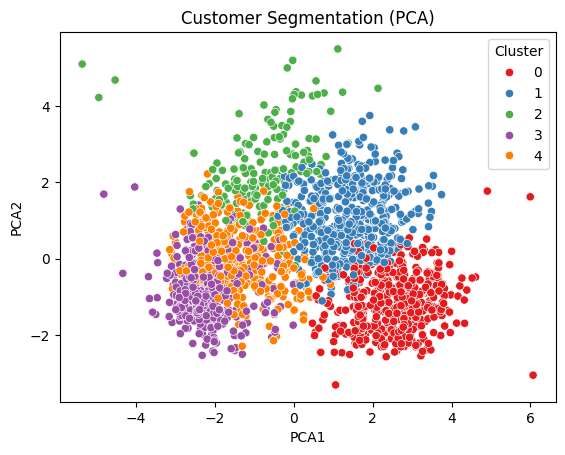

PCA(2) explained variance: 35.6% + 15.7% = 51.3% of total variance


In [46]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(StandardScaler().fit_transform(X))
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segmentation (PCA)')
plt.show()

pc1, pc2 = pca.explained_variance_ratio_
print(f"PCA(2) explained variance: {pc1:.1%} + {pc2:.1%} = {pc1 + pc2:.1%} of total variance")

In [47]:
profile = cluster_profile(df, labels, extra_cols=['TotalNo_Children']).round(2)
profile

,Age,Income,Recency,Customer_Tenure,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,NumDealsPurchases,Teenhome,Kidhome,TotalNo_Children
Cluster,,,,,,,,,,,,,
0,57.16,78419.02,49.79,4765.86,1380.18,4.66,8.22,6.11,2.44,1.09,0.06,0.04,0.10
1,61.80,61582.26,47.89,4849.04,885.08,6.79,8.41,3.64,5.34,2.83,0.91,0.05,0.96
2,57.53,48362.30,49.54,4922.53,490.28,5.63,5.67,2.14,7.42,6.44,0.88,0.90,1.78
3,47.42,29319.31,48.39,4781.78,93.32,2.17,3.07,0.48,6.97,1.77,0.03,0.87,0.90
4,63.20,40871.19,49.95,4713.31,103.76,1.98,3.48,0.63,5.58,1.98,0.94,0.61,1.56


### Cluster Interpretation

Based on `profile` above (matched 1:1 with `config.CLUSTER_NAMES` since k=5 means valid cluster ids are 0–4). Cluster ids here come from the **PCA** pipeline selected above — they don't line up with Experiment A's (no-PCA) ids, which is exactly why `config.CLUSTER_NAMES` was re-derived after switching the default to `use_pca=True` rather than reused as-is.

- **Cluster 0** (n=500) — mid-age (57), highest income (~$78k) and spend (~$1,380), store-heavy, by far the heaviest catalog usage (6.11 purchases/month vs. 0.5–3.6 everywhere else), almost no children (`Teenhome` 0.06, `Kidhome` 0.04), lowest web-visit rate -> **High-Value Customers (No Children)**
- **Cluster 1** (n=520) — older (62), high income (~$62k) and spend (~$885), store-heavy (8.4 purchases/month) and the strongest web buyers too (6.79), almost entirely teen households (`Teenhome` 0.91, `Kidhome` 0.05) -> **Premium Teen-Family Shoppers (Store-Focused)**
- **Cluster 2** (n=198, smallest) — mid-age (58), mid income/spend (~$48k / ~$490), by far the heaviest deal usage (6.44 deal purchases/month vs. ~1–3 everywhere else), large families (`TotalNo_Children` 1.78) -> **Deal-Seeking Large Families**
- **Cluster 3** (n=544, largest) — youngest (47), lowest income (~$29k) and spend (~$93), highest web-visit rate (6.97/month) but low web purchases (2.17) — browsing without buying — mostly young children, not teens (`Kidhome` 0.87, `Teenhome` 0.03) -> **Low-Income Young Families (Browsing, Not Buying)**
- **Cluster 4** (n=454) — oldest (63), low income (~$41k) and spend (~$104), largest households overall (`TotalNo_Children` 1.56, both `Teenhome` 0.94 and `Kidhome` 0.62 elevated) -> **Budget Multi-Child Households**

**What the scatter above shows:** Cluster 0 (`High-Value Customers`) and Cluster 1 (`Premium Teen-Family Shoppers`) sit furthest right and are the most visually distinct pair — consistent with them being the two highest-spend segments (`Total_Spending` ~$1,380 and ~$885, vs. ~$93–490 for the rest). That's not a coincidence: `PCA1`'s loadings are dominated by `Total_Spending` (0.44), `Income` (0.43), and `NumCatalogPurchases` (0.40), so the horizontal axis is essentially a spend/income axis. Clusters 2, 3, and 4 (`Deal-Seeking Large Families`, `Low-Income Young Families`, `Budget Multi-Child Households`) overlap heavily on the left — they're all low-spend, and the two viz axes don't carry the features that actually tell them apart (deal usage, web-visit rate, family composition are what separate them in `profile`, not `PC1`/`PC2`). This is the visual version of the same story `Davies-Bouldin`/`Calinski-Harabasz` told above: real structure, fuzziest among the three lower-spend segments.

**What the PCA step changed:** the same five archetypes as Experiment A come back, at nearly identical sizes (compare `labels_no_pca.value_counts()` above to `df["Cluster"].value_counts()` here — the biggest is the Deal-Seeking Large Families group, 196 rows -> 198). What PCA changes is how cleanly those archetypes separate, not who's in them (0.962 ARI between the two experiments' assignments). `NumCatalogPurchases` remains the feature that most sharply distinguishes Cluster 0 (`High-Value Customers`, 6.11/month) from Cluster 1 (`Premium Teen-Family Shoppers`, 3.64/month) — two segments that look similar on `Total_Spending` and `NumStorePurchases` alone. `Recency` still doesn't distinguish any of these groups — it's essentially flat (47.9–49.9 days) across all five clusters, consistent with its near-zero correlation with every other candidate in [Feature Selection](#Feature-Selection). "Inactive" isn't a trait of any one segment; it has to be applied as a filter *within* a segment (e.g. "inactive High-Value Customers") rather than read off the cluster label. `Customer_Tenure` is similarly flat (4,713–4,923 days) and doesn't distinguish clusters either — both features earned their place in [Feature Selection](#Feature-Selection) as independent axes for the model to use, not as the axes this particular k=5 partition happens to split on.

This maps back to the [Business Goal](#Business-Goal) above: Cluster 0 is the clearest loyalty/upsell target, with Cluster 1 close behind on a teen-family angle — and distinguishable from Cluster 0 by channel, not just spend, thanks to `NumCatalogPurchases`. Cluster 2's extreme deal usage points to a coupon/promotion-led campaign, distinct from Cluster 4's flat-out low engagement despite a similarly low spend. Cluster 3's high-browsing/low-buying pattern is a retargeting or on-site-friction opportunity rather than a spend opportunity. Win-back campaigns should filter by `Recency` within any of these segments, not target a single "inactive" cluster — no cluster is defined by recency.

If your `profile` output doesn't match this, update `config.CLUSTER_NAMES` — that's the single source of truth the app reads from.

## Artifacts

Saved to `config.PIPELINE_PATH` (`models/segmentation_pipeline.pkl`) and `config.METRICS_PATH` (`models/training_metrics.json`).

## Summary & Next Steps

**What this notebook establishes:**
- A reproducible `load → clean → engineer → select → cluster` pipeline, entirely backed by `src/` code — nothing here lives only in the notebook (see [Notebook Purpose & Scope](#Notebook-Purpose-&-Scope)).
- Five customer segments (silhouette 0.200, Davies-Bouldin 1.688, Calinski-Harabasz 579) that are statistically stable (seed ARI 0.998, bootstrap ARI 0.948) *and* map to concrete marketing actions — see [Cluster Interpretation](#Cluster-Interpretation).
- An honest accounting of the model's limits: modest silhouette separation, and two selected features (`Recency`, `Customer_Tenure`) that don't distinguish any single segment on their own.

**If I extended this further, I'd look at:**
- A supervised follow-up (e.g. propensity-to-respond) using `Response`/`AcceptedCmp1–5`, deliberately excluded from clustering in [Feature Selection](#Feature-Selection) so future campaign behavior can't leak into segment membership.
- Re-running [Choosing the Number of Clusters (K)](#Choosing-the-Number-of-Clusters-(K)) periodically as new data arrives, since retail behavior segments drift over time.
- A/B testing the campaign each segment implies in [Cluster Interpretation](#Cluster-Interpretation), to close the loop from *who they are* to *what actually worked*.